# LAB 5

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import label

## Project 1: Edge Detection

read the image first.

Image T1:
Shape: (352, 512)
Data type: float64
MAX value: 769.0
MIN value: 0.0

Image T2:
Shape: (352, 512)
Data type: float64
MAX value: 1127.0
MIN value: 0.0


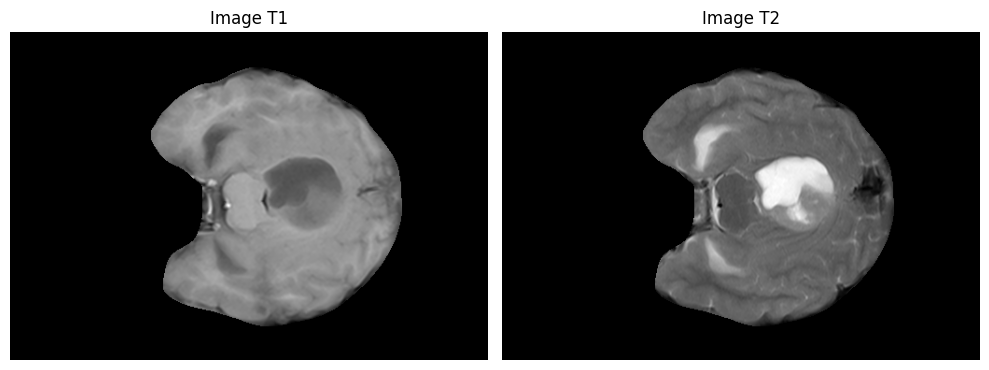

In [2]:
from PIL.ImageShow import show


def show_images_L1(images, titles, cmap='gray'):
    """ show images in a row """
    n = len(images)
    plt.figure(figsize=(n * 5, 5))
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, n, i)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# open the iamge lab4-1.npy
img_T1 = np.load('./input/T1.npy')
img_T2 = np.load('./input/T2.npy')

# show the infromation of the image
print("Image T1:")
print("Shape:", img_T1.shape)
print("Data type:", img_T1.dtype)
print("MAX value:", img_T1.max())
print("MIN value:", img_T1.min())

print("\nImage T2:")
print("Shape:", img_T2.shape)
print("Data type:", img_T2.dtype)
print("MAX value:", img_T2.max())
print("MIN value:", img_T2.min())

# show the image
show_images_L1(
    images=[img_T1, img_T2],
    titles=['Image T1', 'Image T2']
)

### For T1

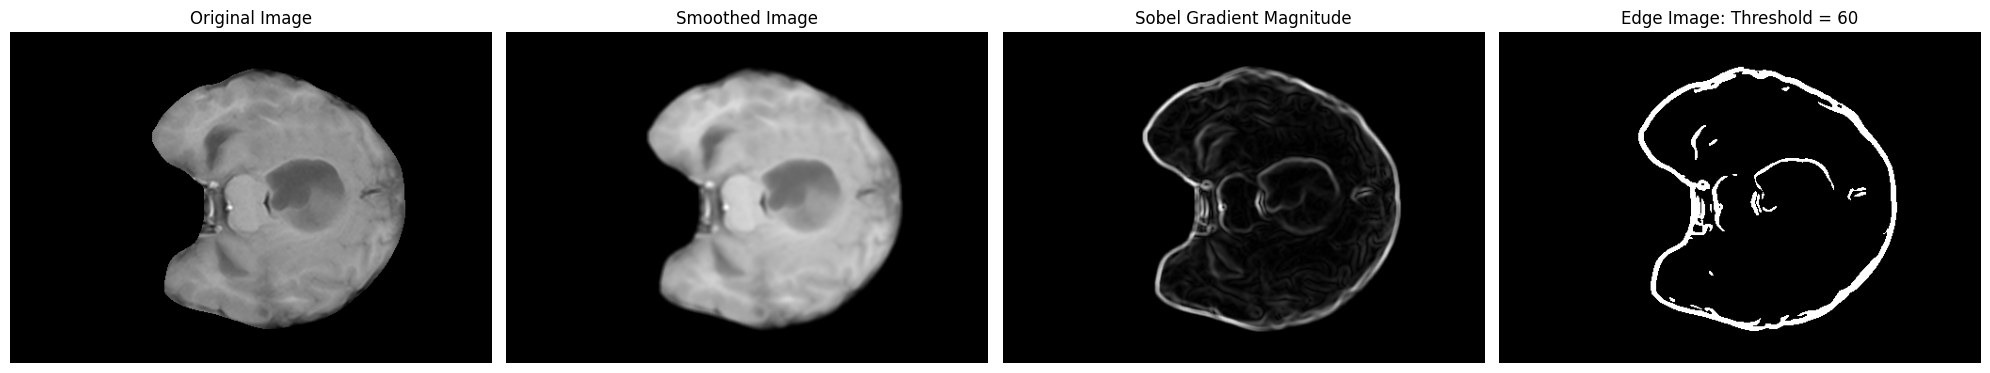

In [3]:
# original image
img_T1 = np.load('./input/T1.npy')

# smooth filter
img_T1_smooth = cv2.blur(img_T1, (5, 5))

# Sobel filter
Kx = np.array([[1, 0, -1], 
               [2, 0, -2],
               [1, 0, -1]])
Ky = np.array([[1, 2, 1],
               [0, 0, 0],
               [-1, -2, -1]])
Gx = cv2.filter2D(img_T1_smooth.astype(np.float32), -1, Kx)
Gy = cv2.filter2D(img_T1_smooth.astype(np.float32), -1, Ky)
G = np.sqrt(Gx**2 + Gy**2)
G = (G / G.max() * 255).astype(np.uint8)

# threshold T
threshold_T1 = 60
_, img_T1_edge = cv2.threshold(G, threshold_T1, 255, cv2.THRESH_BINARY)

# show the image
show_images_L1(
    images=[img_T1, img_T1_smooth, G, img_T1_edge],
    titles=['Original Image', 'Smoothed Image', 'Sobel Gradient Magnitude', f'Edge Image: Threshold = {threshold_T1}']
)


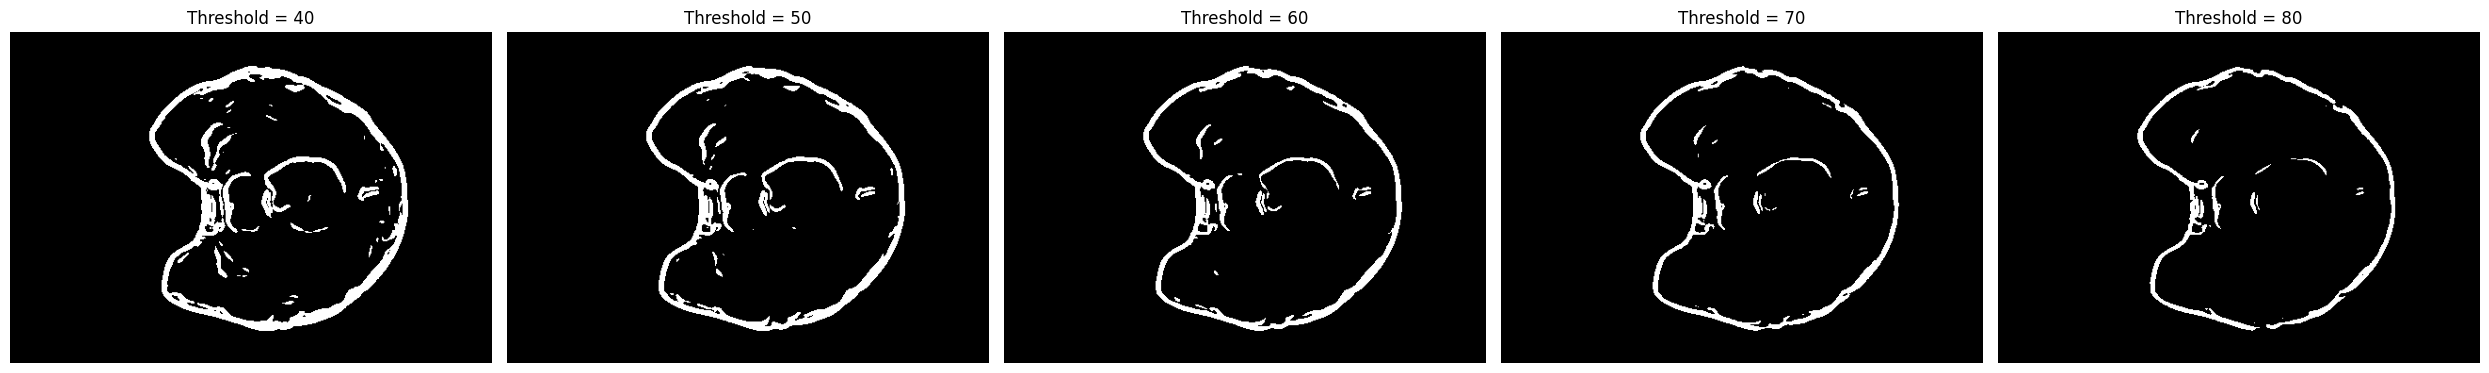

In [4]:
# try different threshold
threshold_T1_list = [40, 50, 60, 70, 80]
edge_images = []
for T in threshold_T1_list:
    _, edge_img = cv2.threshold(G, T, 255, cv2.THRESH_BINARY)
    edge_images.append(edge_img)

# show the image
show_images_L1(
    images=edge_images,
    titles=[f'Threshold = {T}' for T in threshold_T1_list]
)

将 Sobel Filter 和 Brain edge 封装一下，方便重复调用。

In [5]:
# sobel filter
def filterSobel(image):
    Kx = np.array([[1, 0, -1], 
                   [2, 0, -2],
                   [1, 0, -1]])
    Ky = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]])
    Gx = cv2.filter2D(image.astype(np.float32), -1, Kx)
    Gy = cv2.filter2D(image.astype(np.float32), -1, Ky)
    G = np.sqrt(Gx**2 + Gy**2)
    G = (G / G.max() * 255).astype(np.uint8)
    return G

# get the brain edge
def getBrainEdge(image, threshold: int = 50):
    smooth = cv2.blur(image, (5, 5))
    smooth = cv2.normalize(smooth, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    brain_mask = smooth.copy()
    brain_mask[brain_mask < threshold] = 0
    brain_mask[brain_mask >= threshold] = 255
    
    
    kernel = np.ones((5,5), np.uint8)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_CLOSE, kernel)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, kernel)
    
    G = filterSobel(brain_mask)
    _, brain_edge = cv2.threshold(G, threshold, 255, cv2.THRESH_BINARY)
    
    return brain_edge

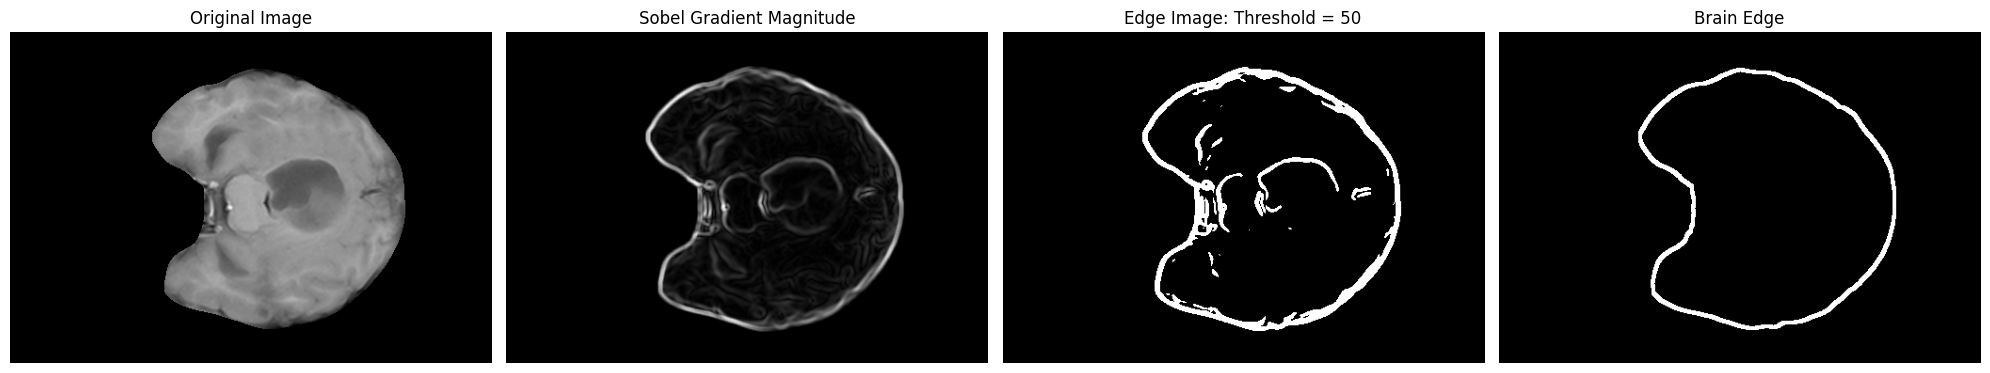

In [6]:
# original image
img_T1 = np.load('./input/T1.npy')

# brain edge
img_T1_brain_edge = getBrainEdge(img_T1, threshold=50)
kernel_dilate_operation = np.ones((3, 3), np.uint8)
img_T1_brain_edge = cv2.dilate(img_T1_brain_edge, kernel_dilate_operation, iterations=1)

# smooth filter
img_T1_smooth = cv2.blur(img_T1, (5, 5))

# Sobel filter
G = filterSobel(img_T1_smooth)

# threshold T
threshold_T1 = 50
_, img_T1_edge = cv2.threshold(G, threshold_T1, 255, cv2.THRESH_BINARY)

# show the image
show_images_L1(
    images=[img_T1, G, img_T1_edge, img_T1_brain_edge],
    titles=['Original Image', 'Sobel Gradient Magnitude', f'Edge Image: Threshold = {threshold_T1}', 'Brain Edge']
)

- remove brain edge

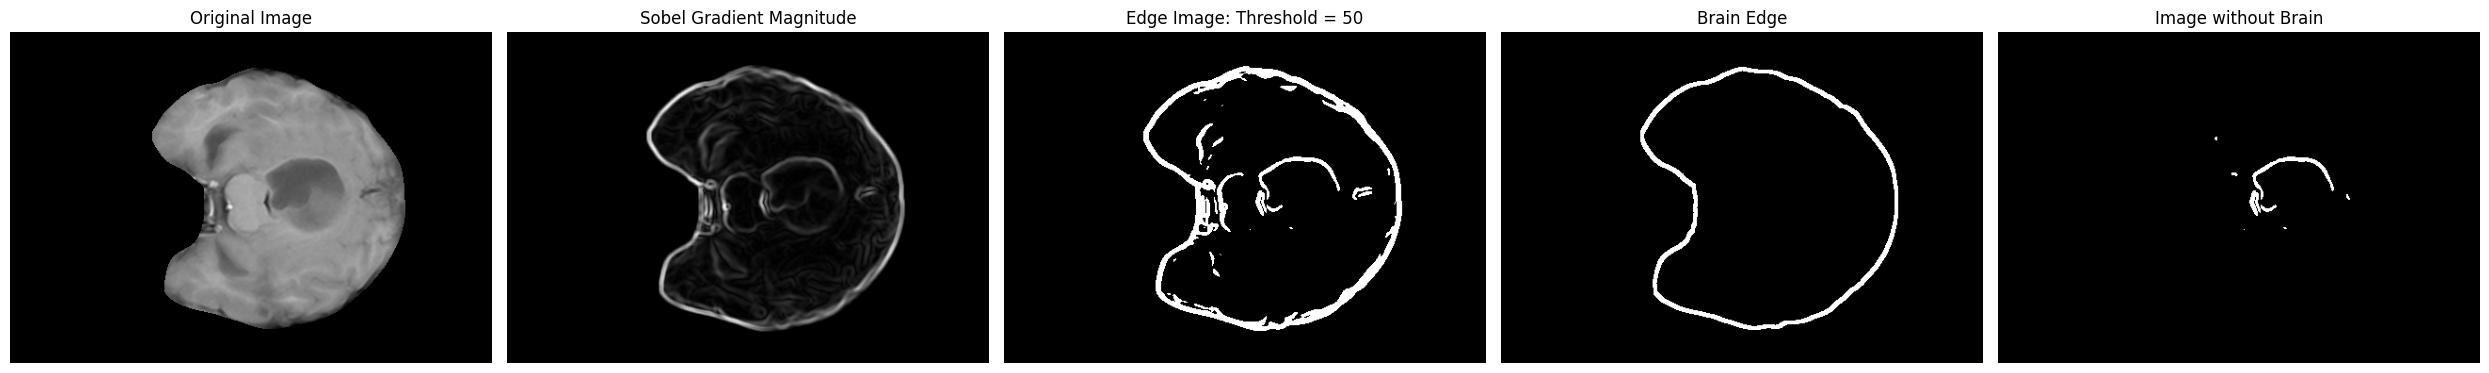

In [7]:
def removeBrainEdge(image, edge, kernel: tuple = (79, 79)):
    edge = cv2.blur(edge, kernel)
    mask = image.copy()
    mask[edge > 0] = 0
    return mask

# remove brain edge from the edge image
img_T1_no_brain_edge = removeBrainEdge(img_T1_edge, img_T1_brain_edge)

show_images_L1(
    images=[img_T1, G, img_T1_edge, img_T1_brain_edge, img_T1_no_brain_edge],
    titles=['Original Image', 'Sobel Gradient Magnitude', f'Edge Image: Threshold = {threshold_T1}', 'Brain Edge', 'Image without Brain']
)

There are many white point around the lesion, use morpyology method to delete them.

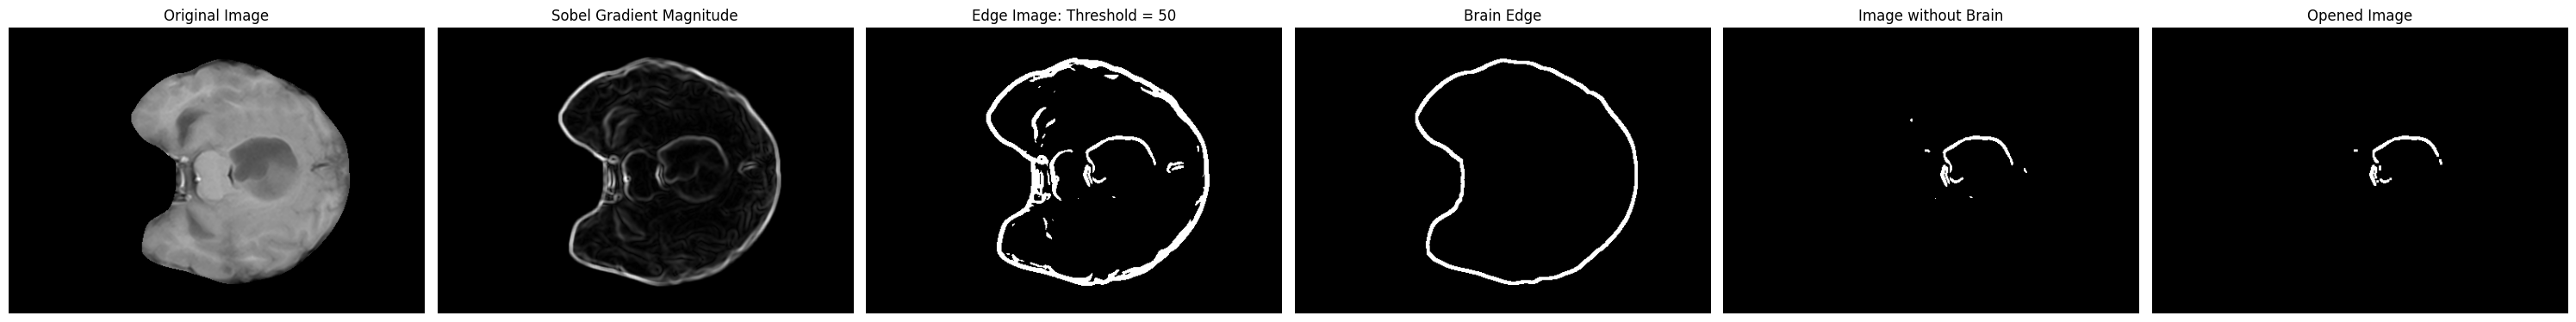

In [8]:
# remove brain edge from the edge image
img_T1_no_brain_edge = removeBrainEdge(img_T1_edge, img_T1_brain_edge)

# perform morphological operations
kernel_open_operation = np.ones((3, 3), np.uint8)
img_T1_opened = cv2.morphologyEx(img_T1_no_brain_edge, cv2.MORPH_OPEN, kernel_open_operation)

show_images_L1(
    images=[img_T1, G, img_T1_edge, img_T1_brain_edge, img_T1_no_brain_edge, img_T1_opened],
    titles=['Original Image', 'Sobel Gradient Magnitude', f'Edge Image: Threshold = {threshold_T1}', 'Brain Edge', 'Image without Brain', 'Opened Image']
)

- Closed Operation

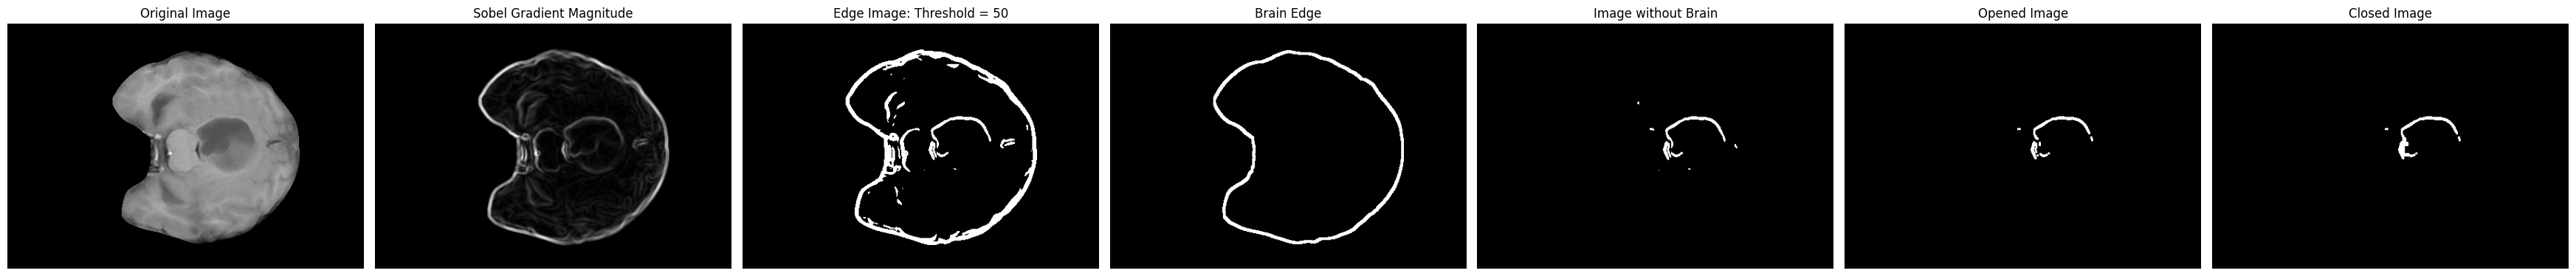

In [9]:
kernel_close_operation = np.ones((5, 5), np.uint8)
img_T1_closed = cv2.morphologyEx(img_T1_opened, cv2.MORPH_CLOSE, kernel_close_operation)

show_images_L1(
    images=[img_T1, G, img_T1_edge, img_T1_brain_edge, img_T1_no_brain_edge,img_T1_opened, img_T1_closed],
    titles=['Original Image', 'Sobel Gradient Magnitude', f'Edge Image: Threshold = {threshold_T1}', 'Brain Edge', 'Image without Brain', 'Opened Image', 'Closed Image']
)

- Connected domain processing

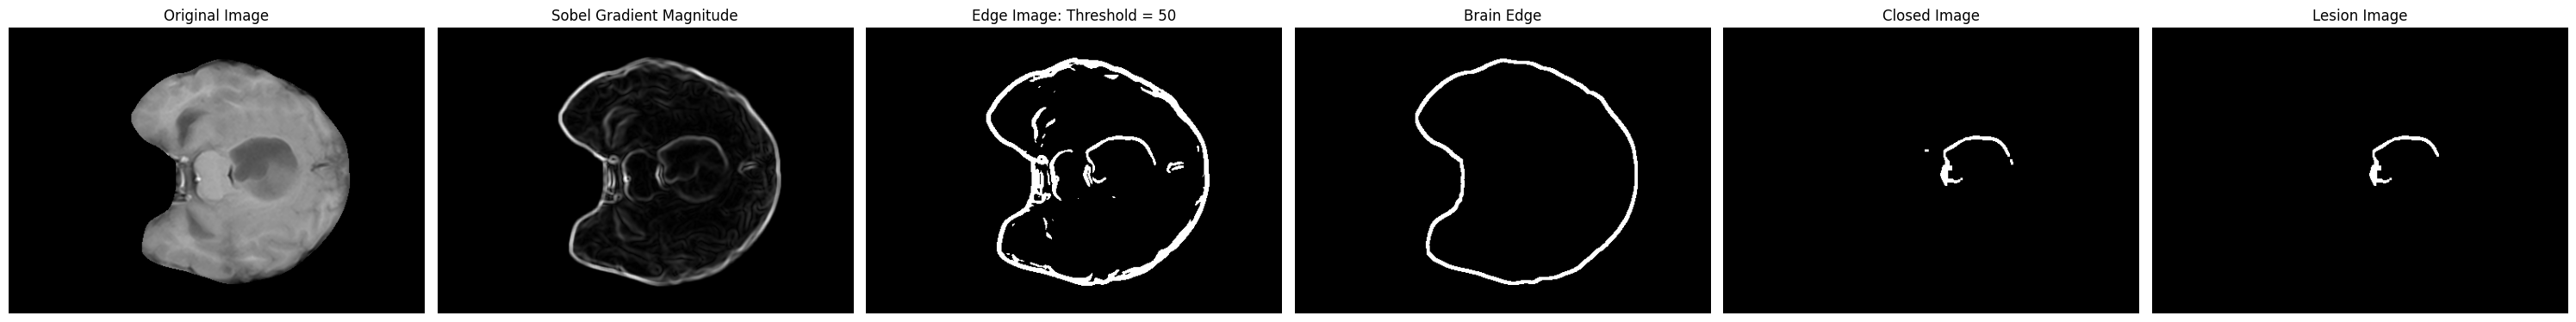

In [10]:
img_T1_labeled, num_features = label(img_T1_closed)
if num_features == 0:
    img_T1_lesion = img_T1_closed
else:
    max_label = 1 + np.argmax([np.sum(img_T1_labeled==i) for i in range(1, num_features+1)])
    img_T1_lesion = np.zeros_like(img_T1_closed)
    img_T1_lesion[img_T1_labeled == max_label] = 255

# show the final image
show_images_L1(
    images=[img_T1, G, img_T1_edge, img_T1_brain_edge, img_T1_closed, img_T1_lesion],
    titles=['Original Image', 'Sobel Gradient Magnitude', f'Edge Image: Threshold = {threshold_T1}', 'Brain Edge', 'Closed Image', 'Lesion Image']
)

mark the original image

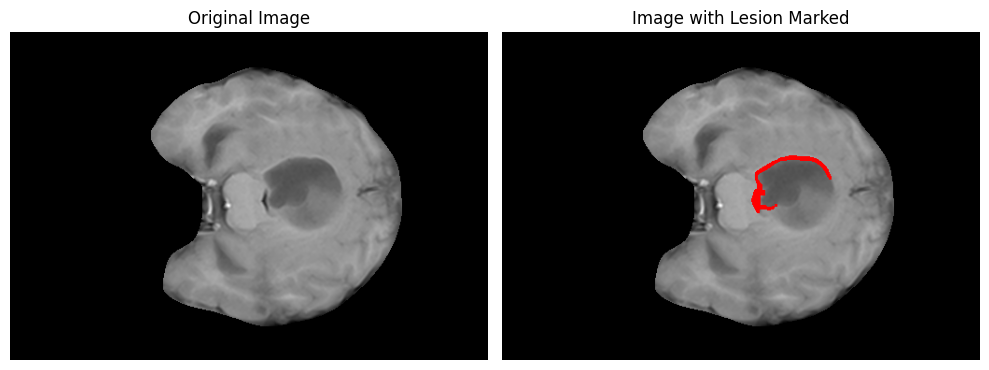

In [11]:
def markLesion(image, lesion_mask, color=(255, 0, 0)):
    gray_uint8 = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    result_img = cv2.cvtColor(gray_uint8, cv2.COLOR_GRAY2RGB)
    result_img[lesion_mask > 0] = color 
    return result_img

# mark the lesion on the original image
img_T1_marked = markLesion(img_T1, img_T1_lesion)
show_images_L1(
    images=[img_T1, img_T1_marked],
    titles=['Original Image', 'Image with Lesion Marked']
)

### For T1 & T2

将以上处理过程封装成函数，并处理 T2.

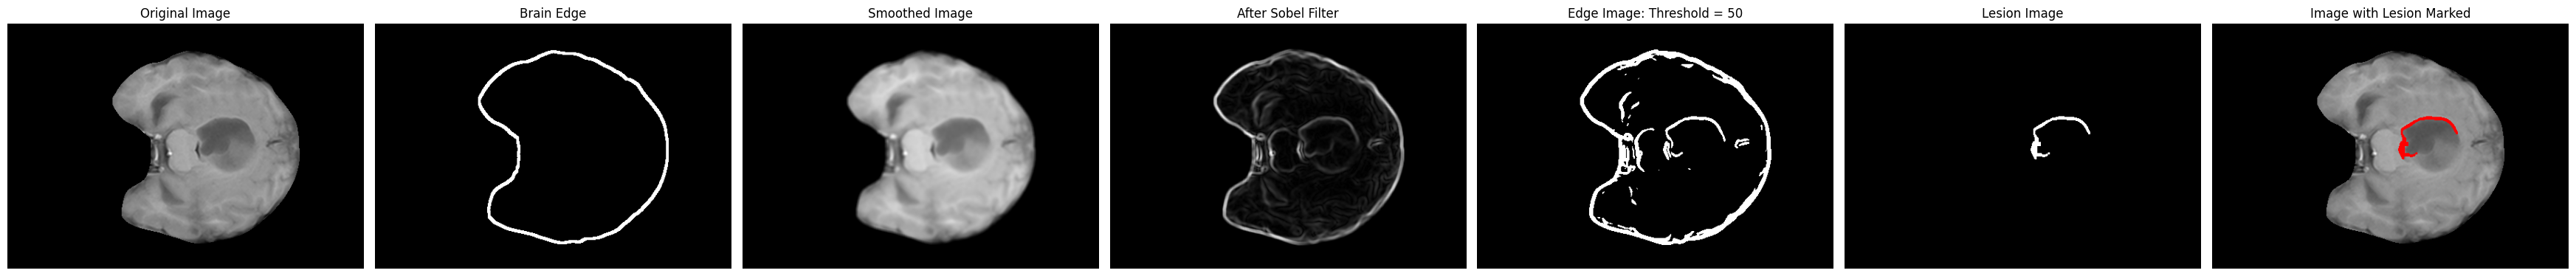

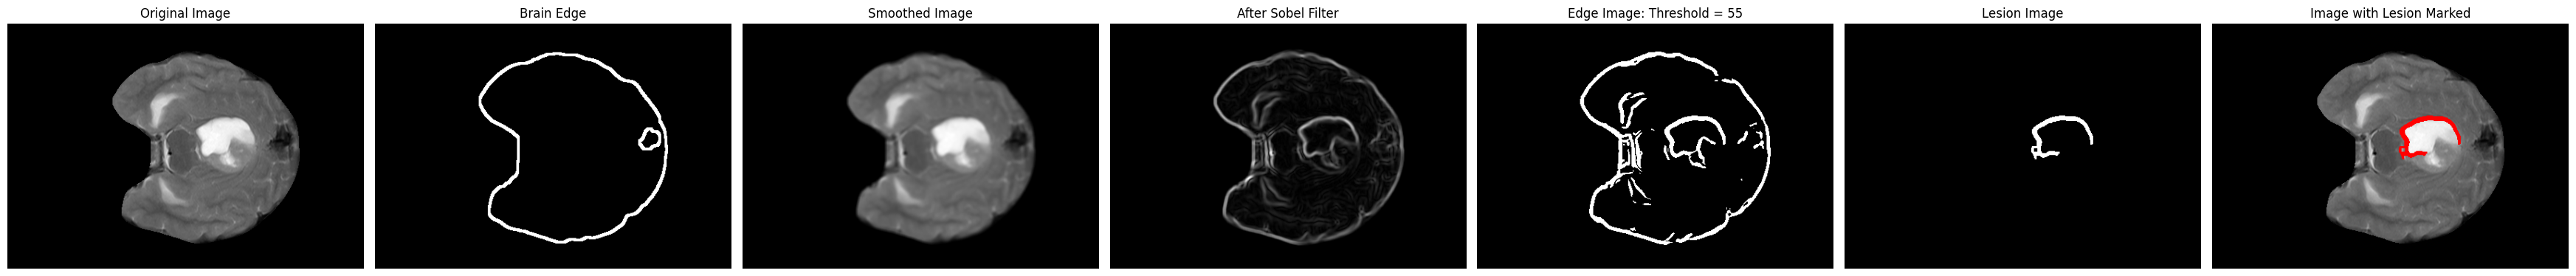

In [12]:
def processLesionSegmentation(image, threshold: int = 100, kernel: tuple = (79, 79)):

    # result
    result = {
        "images": [],
        "titles": []
    }
    result["images"].append(image)
    result["titles"].append("Original Image")

    # brain edge
    image_brain_edge = getBrainEdge(image, threshold=50)
    kernel_dilate_operation = np.ones((3, 3), np.uint8)
    image_brain_edge = cv2.dilate(image_brain_edge, kernel_dilate_operation, iterations=1)
    result["images"].append(image_brain_edge)
    result["titles"].append("Brain Edge")

    # smooth filter
    image_smooth = cv2.blur(image, (5, 5))
    result["images"].append(image_smooth)
    result["titles"].append("Smoothed Image")

    # Sobel filter
    G = filterSobel(image_smooth)
    result["images"].append(G)
    result["titles"].append("After Sobel Filter")

    # threshold T
    _, image_edge = cv2.threshold(G, threshold, 255, cv2.THRESH_BINARY)
    result["images"].append(image_edge)
    result["titles"].append(f"Edge Image: Threshold = {threshold}")

    # remove brain edge from the edge image
    image_no_brain_edge = removeBrainEdge(image_edge, image_brain_edge, kernel=kernel)
    # perform morphological operations: open
    kernel_open_operation = np.ones((3, 3), np.uint8)
    image_opened = cv2.morphologyEx(image_no_brain_edge, cv2.MORPH_OPEN, kernel_open_operation)
    # perform morphological operations: close
    kernel_close_operation = np.ones((5, 5), np.uint8)
    image_closed = cv2.morphologyEx(image_opened, cv2.MORPH_CLOSE, kernel_close_operation)


    # connected component analysis
    image_labeled, num_features = label(image_closed)
    if num_features == 0:
        image_lesion = image_closed
    else:
        max_label = 1 + np.argmax([np.sum(image_labeled==i) for i in range(1, num_features+1)])
        image_lesion = np.zeros_like(image_closed)
        image_lesion[image_labeled == max_label] = 255
    result["images"].append(image_lesion)
    result["titles"].append("Lesion Image")

    # mark the lesion on the original image
    image_marked = markLesion(image, image_lesion)
    result["images"].append(image_marked)
    result["titles"].append("Image with Lesion Marked")

    return result

# test
threshold_T1 = 50
kernel_T1 = (7, 7)
threshold_T2 = 55
kernel_T2 = (5, 5)

result_T1 = processLesionSegmentation(img_T1, threshold=threshold_T1, kernel=kernel_T1)
result_T2 = processLesionSegmentation(img_T2, threshold=threshold_T2, kernel=kernel_T2)

show_images_L1(
    images=result_T1["images"],
    titles=result_T1["titles"]
)

show_images_L1(
    images=result_T2["images"],
    titles=result_T2["titles"]
)

## Project 2: Thresholding

### 2.1 Implement Iterative global threshold segmentation

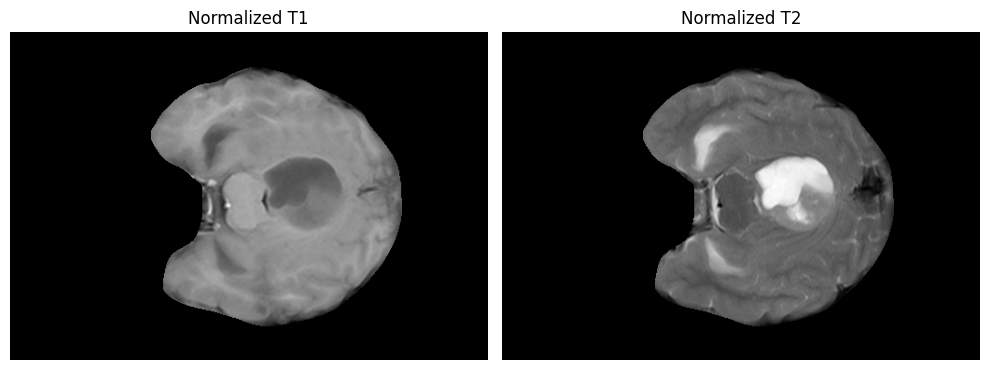

In [13]:
def normalize(image, dtype: np.dtype = np.uint8):
    return cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(dtype)

img_T1_normalized = normalize(img_T1)
img_T2_normalized = normalize(img_T2)

show_images_L1(
    images=[img_T1_normalized, img_T2_normalized],
    titles=["Normalized T1", "Normalized T2"]
)

Iterative Threshold for T1: 67.13435984236317


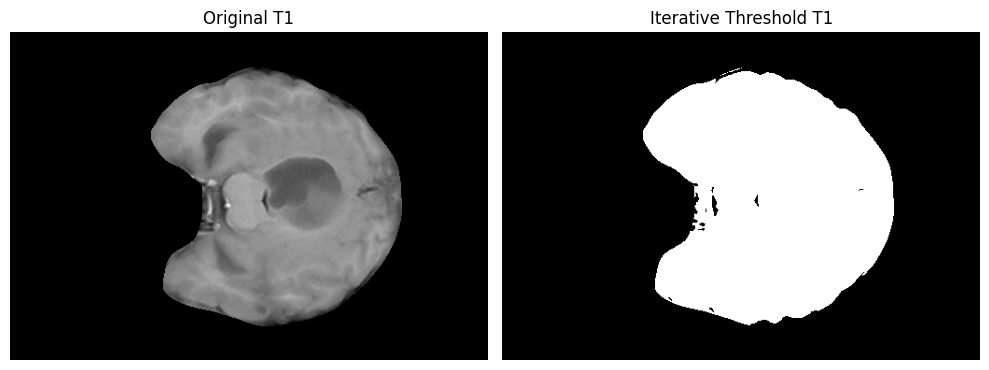

Iterative Threshold for T2: 55.52047384188302


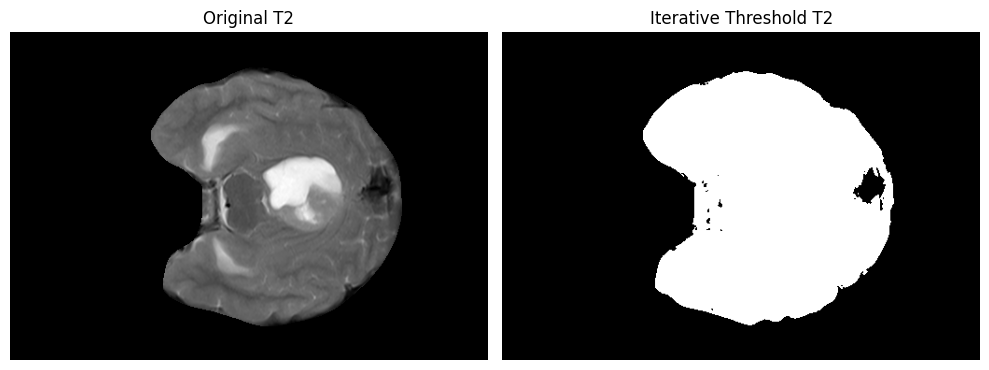

In [14]:
def thresholdIterative(image, T_init: int = 100, tolerance: int = 1, max_iterations: int = 100, dtype: np.dtype = np.uint8):
    T = T_init
    image = normalize(image, dtype=dtype)
    for i in range(max_iterations):
        lower = image[image <= T]
        upper = image[image > T]
        if len(lower) == 0 or len(upper) == 0:
            break
        T_new = (lower.mean() + upper.mean()) / 2
        if abs(T - T_new) < tolerance:
            break
        T = T_new
    mask = np.zeros_like(image, dtype=dtype)
    mask[image > T] = 255
    return mask, T

T_init = 100
tolerance = 1
max_iterations = 100
mask_T1_iter, T1_iter = thresholdIterative(img_T1, T_init=T_init, tolerance=tolerance, max_iterations=max_iterations)
mask_T2_iter, T2_iter = thresholdIterative(img_T2, T_init=T_init, tolerance=tolerance, max_iterations=max_iterations)

print(f"Iterative Threshold for T1: {T1_iter}")
show_images_L1(
    images=[img_T1_normalized, mask_T1_iter],
    titles=["Original T1", "Iterative Threshold T1"]
)

print(f"Iterative Threshold for T2: {T2_iter}")
show_images_L1(
    images=[img_T2_normalized, mask_T2_iter],
    titles=["Original T2", "Iterative Threshold T2"]
)

add histogram function and show them

Iterative Threshold for T1: 67.13435984236317


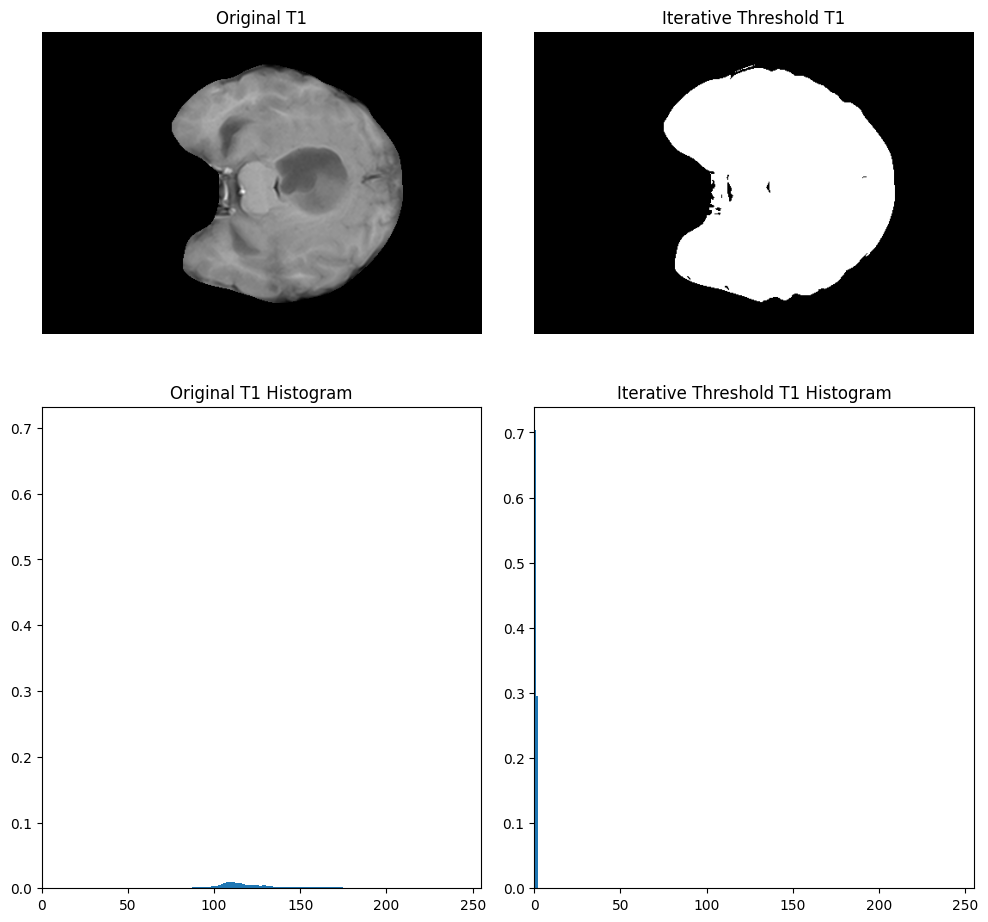

Iterative Threshold for T2: 55.52047384188302


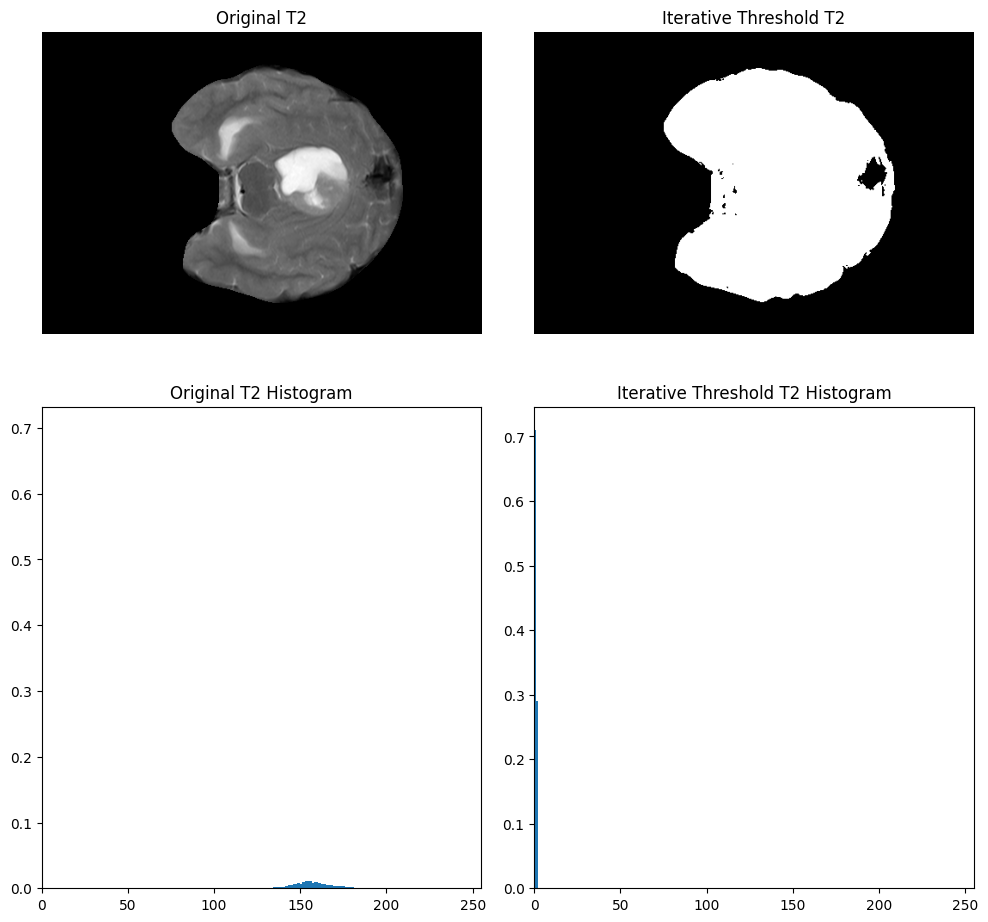

In [15]:
def quantify_histogram(img, dtype: np.dtype = np.uint8):
    """
    quantify the image according to the histogram
    """

    # change the image to dtype
    img = img.astype(dtype)
    image_min = img.min()
    image_max = img.max()

    if image_max == image_min:
        output_image = np.zeros(256, dtype=dtype)
        output_image[0] = 1.0
        return output_image

    # normalize the image
    image_norm = normalize(img, dtype=dtype)
    image_quantized = np.clip((image_norm * 255).astype(np.int32), 0, 255)

    output_image = np.bincount(image_quantized.ravel(), minlength=256).astype(np.float32)
    output_image = output_image / output_image.sum()
    return output_image

def show_images_histogram(images, titles, figsize=(15, 5), cmap='gray'):
    """ show images in a row """
    fig, axes = plt.subplots(2, len(images), figsize=(5 * len(images), 10))
    bins = np.arange(256)
    for i, (img, title) in enumerate(zip(images, titles)):
        # first row: images
        axes[0, i].imshow(normalize(img), cmap=cmap)
        axes[0, i].set_title(title)
        axes[0, i].axis('off')

        # second row: histograms
        images_hist = quantify_histogram(img)
        axes[1, i].bar(bins, images_hist, width=2.0)
        axes[1, i].set_title(f'{title} Histogram')
        axes[1, i].set_xlim(0, 255)

    plt.tight_layout()
    plt.show()

print(f"Iterative Threshold for T1: {T1_iter}")
show_images_histogram(
    images=[img_T1_normalized, mask_T1_iter],
    titles=["Original T1", "Iterative Threshold T1"]
)

print(f"Iterative Threshold for T2: {T2_iter}")
show_images_histogram(
    images=[img_T2_normalized, mask_T2_iter],
    titles=["Original T2", "Iterative Threshold T2"]
)

背景数量太高了，很容易把背景分为一类，要想办法把背景剔除出去。

Iterative Threshold for T1: 116.28879911470014


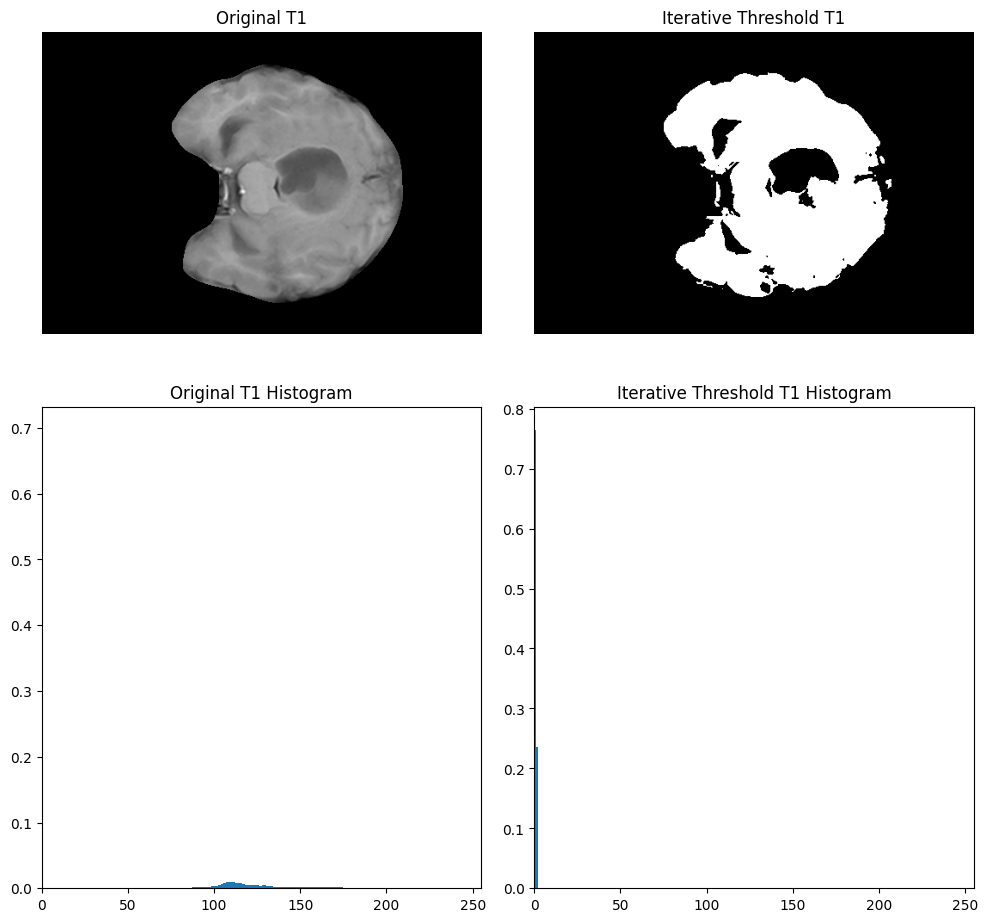

Iterative Threshold for T2: 151.3743447774998


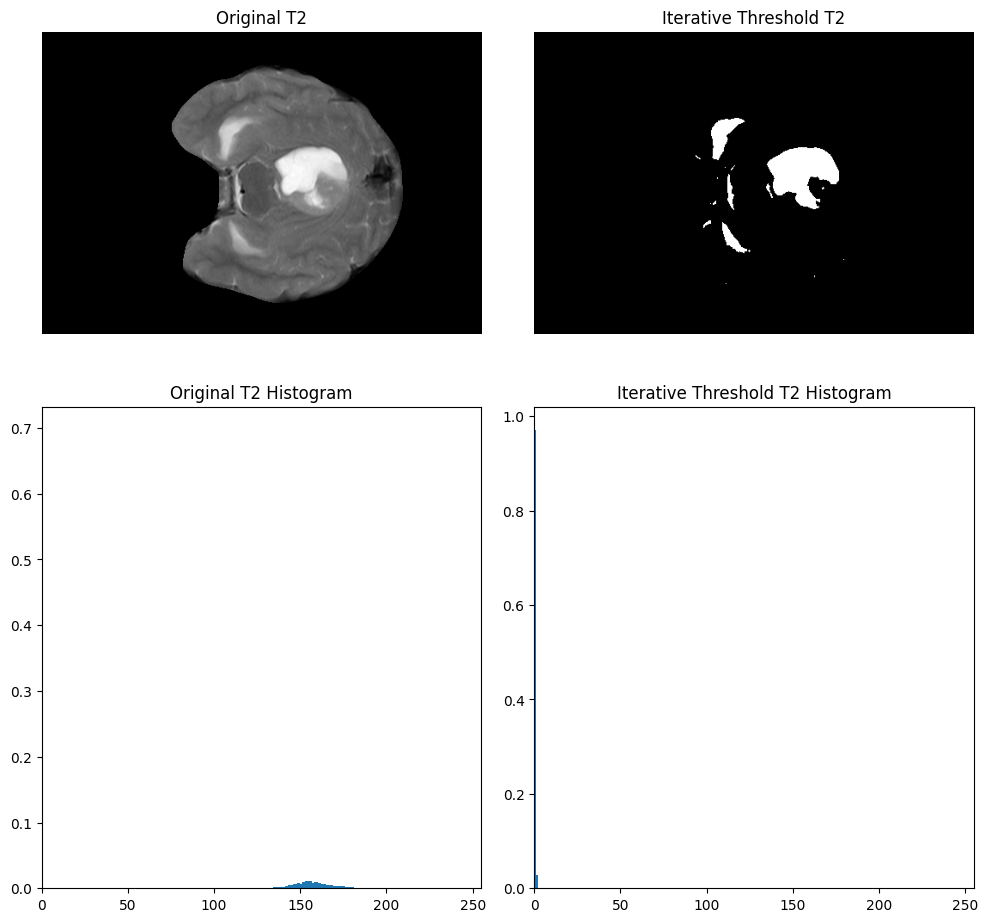

In [16]:
def thresholdIterative(image, T_init: int = 100, tolerance: int = 1, max_iterations: int = 100, dtype: np.dtype = np.uint8):
    T = T_init
    image = normalize(image, dtype=dtype)
    signal_mask = (image > 0)
    for i in range(max_iterations):
        signal = image[signal_mask]
        lower = signal[signal <= T]
        upper = signal[signal > T]
        if len(lower) == 0 or len(upper) == 0:
            break
        T_new = (lower.mean() + upper.mean()) / 2
        if abs(T - T_new) < tolerance:
            break
        T = T_new
    mask = np.zeros_like(image, dtype=dtype)
    mask[image > T] = 255
    return mask, T

T_init = 100
tolerance = 1
max_iterations = 100
mask_T1_iter, T1_iter = thresholdIterative(img_T1, T_init=T_init, tolerance=tolerance, max_iterations=max_iterations)
mask_T2_iter, T2_iter = thresholdIterative(img_T2, T_init=T_init, tolerance=tolerance, max_iterations=max_iterations)

print(f"Iterative Threshold for T1: {T1_iter}")
show_images_histogram(
    images=[img_T1_normalized, mask_T1_iter],
    titles=["Original T1", "Iterative Threshold T1"]
)

print(f"Iterative Threshold for T2: {T2_iter}")
show_images_histogram(
    images=[img_T2_normalized, mask_T2_iter],
    titles=["Original T2", "Iterative Threshold T2"]
)

test different T_init

Iterative Threshold for T1 with initial T=20: 117.67
Iterative Threshold for T1 with initial T=50: 117.67
Iterative Threshold for T1 with initial T=100: 117.67
Iterative Threshold for T1 with initial T=150: 118.12
Iterative Threshold for T1 with initial T=200: 118.12


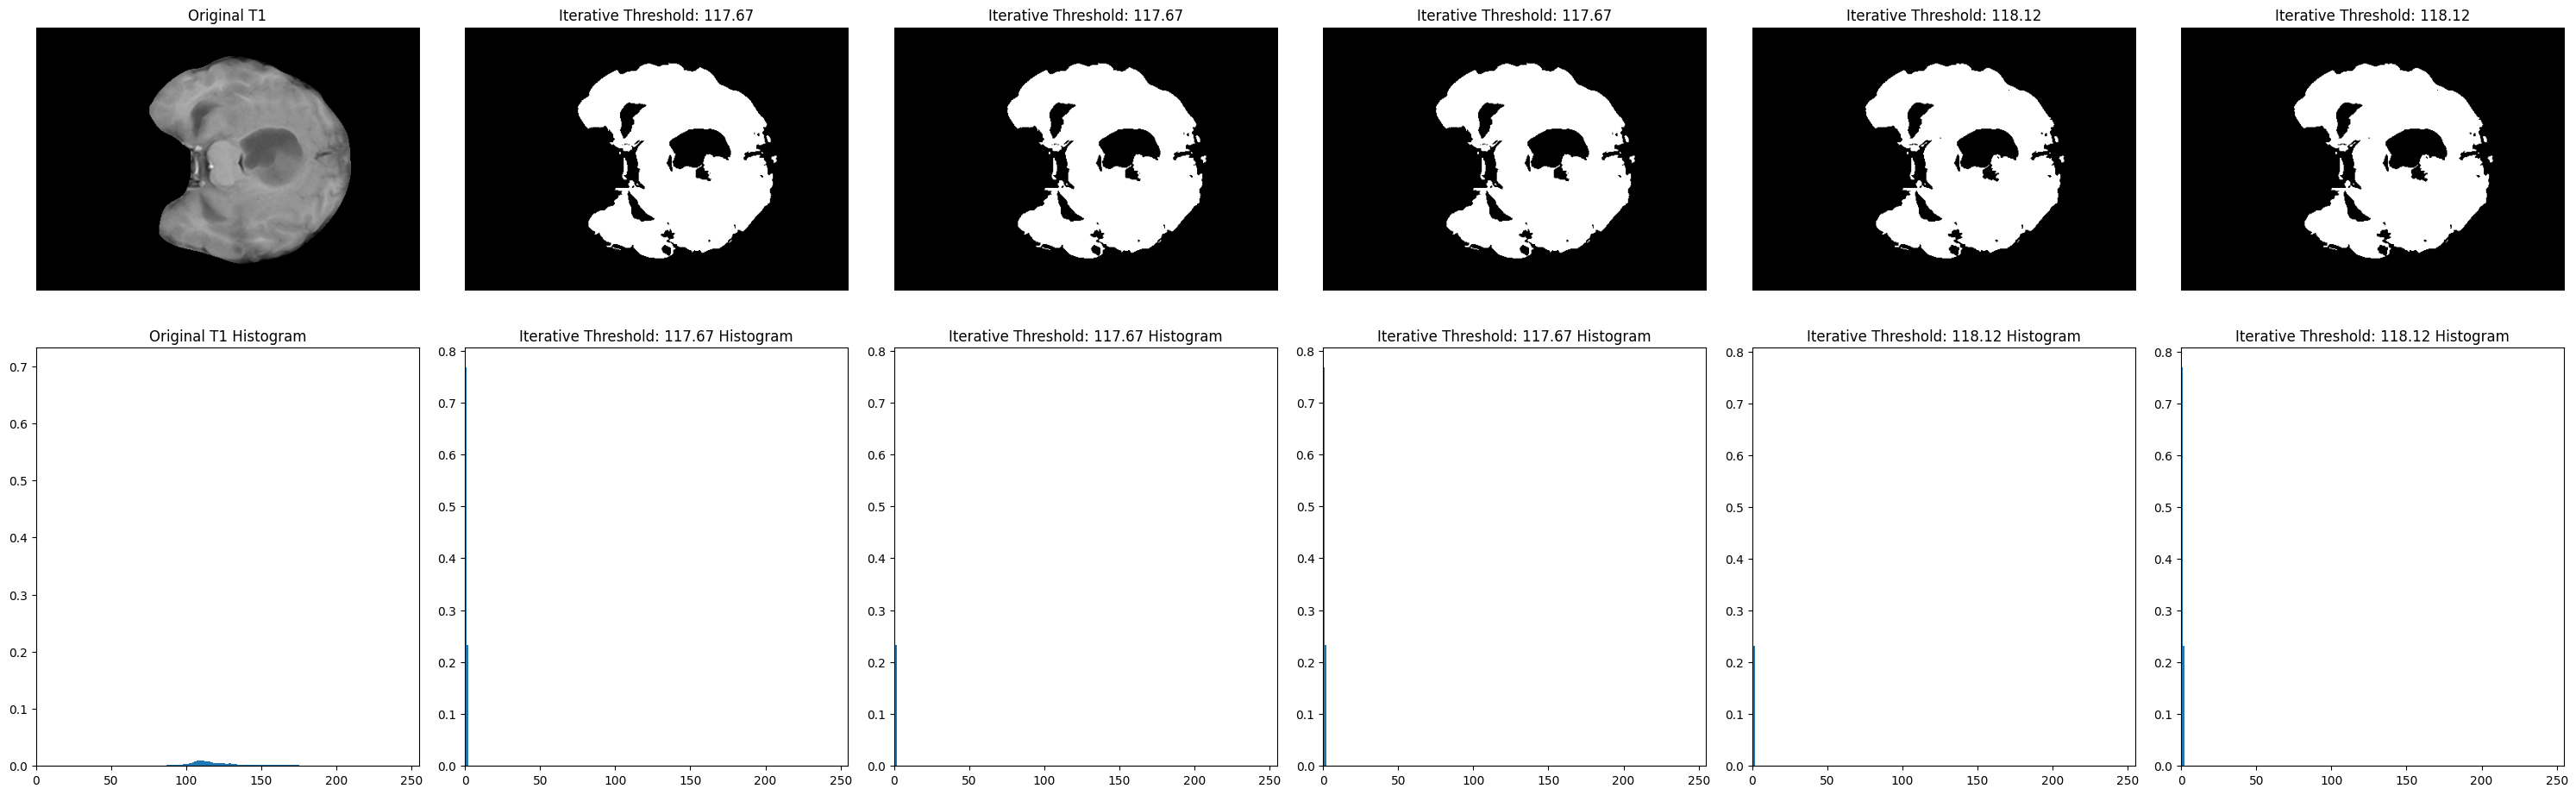

In [36]:
tolerance = 0
max_iterations = 100
T_init_list = [20, 50, 100, 150, 200]
result_T1 = {
    "images": [img_T1_normalized],
    "threshold": [],
    "titles": ["Original T1"]
}

for T in T_init_list:
    mask, threshold = thresholdIterative(img_T1, T_init=T, tolerance=tolerance, max_iterations=max_iterations)
    result_T1["images"].append(mask)
    result_T1["threshold"].append(threshold)
    result_T1["titles"].append(f"Iterative Threshold: {threshold:.2f}")
    print(f"Iterative Threshold for T1 with initial T={T}: {threshold:.2f}")


show_images_histogram(
    images=result_T1["images"],
    titles=result_T1["titles"]
)

对比以上结果可以发现，当选取不同的 `initial T` 时，只要 `tolernce` 足够小并且 `max_iterations` 足够大，最后迭代结果的阈值 `threshold` 都会收敛到一个值。虽然如上数据中，最后的阈值略有差异，但是差异都小于 1 。从分割的结果来看，确实感觉不出什么差异。

试试 T2

Iterative Threshold for T1 with initial T=20: 117.67
Iterative Threshold for T1 with initial T=50: 117.67
Iterative Threshold for T1 with initial T=100: 117.67
Iterative Threshold for T1 with initial T=150: 118.12
Iterative Threshold for T1 with initial T=200: 118.12
Iterative Threshold for T2 with initial T=20: 152.39
Iterative Threshold for T2 with initial T=50: 152.39
Iterative Threshold for T2 with initial T=100: 152.39
Iterative Threshold for T2 with initial T=150: 152.39
Iterative Threshold for T2 with initial T=200: 152.39


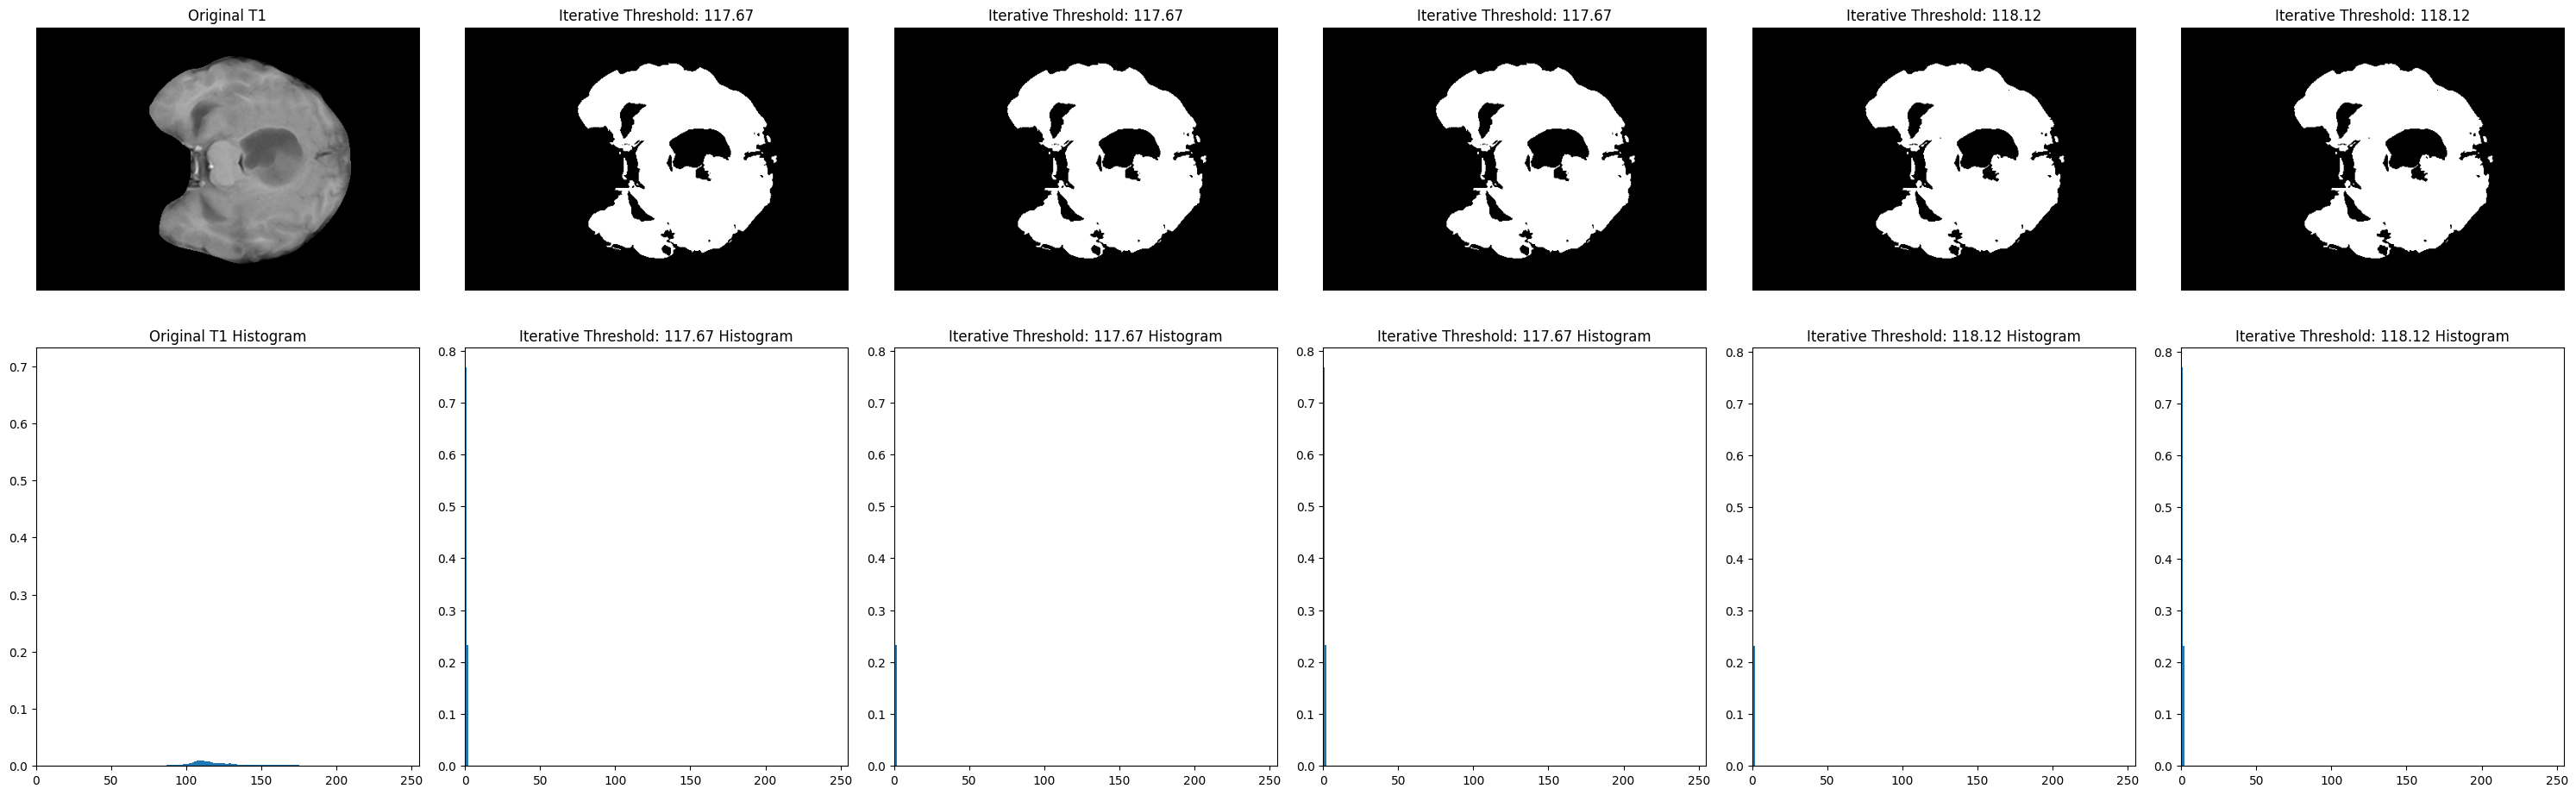

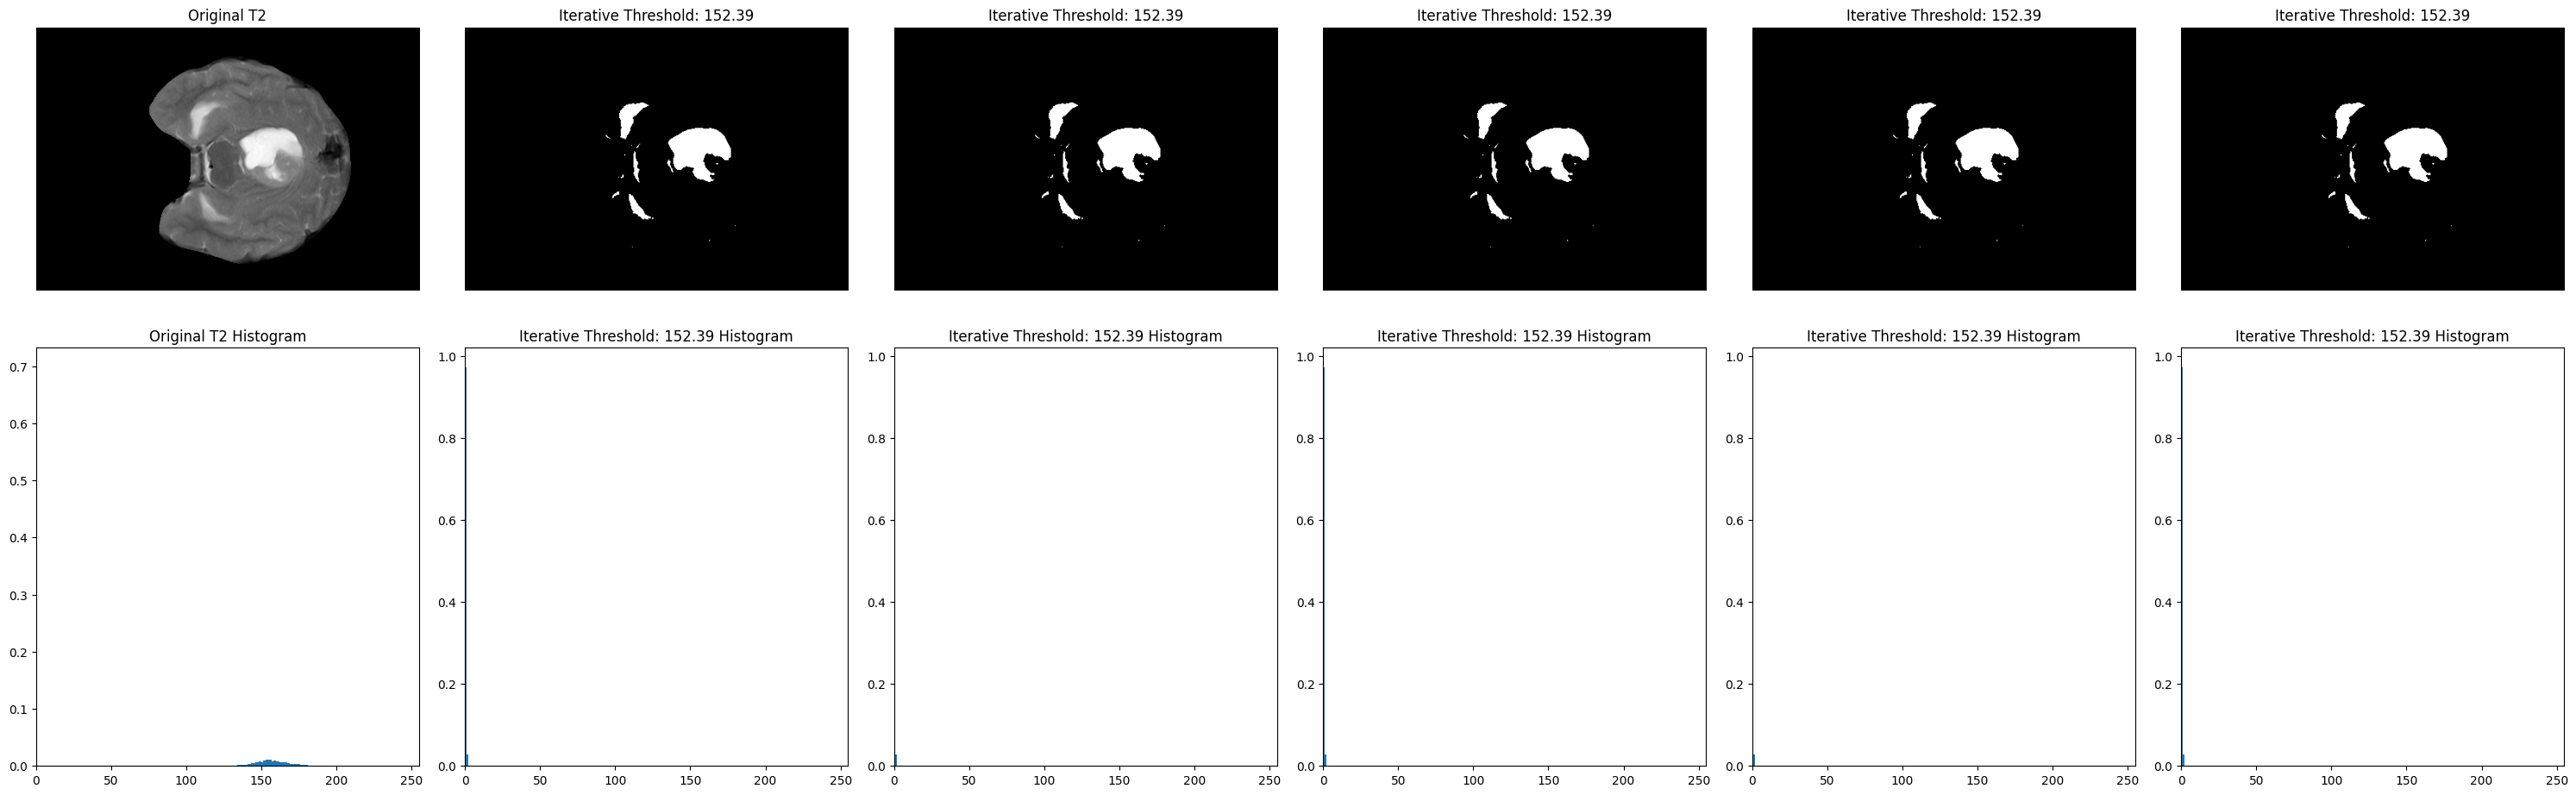

In [37]:
tolerance = 0
max_iterations = 100
T_init_list = [20, 50, 100, 150, 200]
result_T1 = {
    "images": [img_T1_normalized],
    "threshold": [],
    "titles": ["Original T1"]
}
result_T2 = {
    "images": [img_T2_normalized],
    "threshold": [],
    "titles": ["Original T2"]
}

# Apply iterative thresholding for each initial threshold
for T in T_init_list:
    mask, threshold = thresholdIterative(img_T1, T_init=T, tolerance=tolerance, max_iterations=max_iterations)
    result_T1["images"].append(mask)
    result_T1["threshold"].append(threshold)
    result_T1["titles"].append(f"Iterative Threshold: {threshold:.2f}")

    mask, threshold = thresholdIterative(img_T2, T_init=T, tolerance=tolerance, max_iterations=max_iterations)
    result_T2["images"].append(mask)
    result_T2["threshold"].append(threshold)
    result_T2["titles"].append(f"Iterative Threshold: {threshold:.2f}")

# print the thresholds
for i in range(len(T_init_list)):
    print(f"Iterative Threshold for T1 with initial T={T_init_list[i]}: {result_T1['threshold'][i]:.2f}")

for i in range(len(T_init_list)):
    print(f"Iterative Threshold for T2 with initial T={T_init_list[i]}: {result_T2['threshold'][i]:.2f}")


# Display the results
show_images_histogram(
    images=result_T1["images"],
    titles=result_T1["titles"]
)

show_images_histogram(
    images=result_T2["images"],
    titles=result_T2["titles"]
)

从 T1 和 T2 的结果来看，在 `max_iterations` 较大时，迭代次数较大。此时，选取不同的 `T_init` 对结果没有什么影响，阈值都能收敛到一个较为合理的值。

Iterative Threshold for T1 with initial T=20: 73.18
Iterative Threshold for T1 with initial T=50: 83.78
Iterative Threshold for T1 with initial T=100: 110.52
Iterative Threshold for T1 with initial T=150: 141.81
Iterative Threshold for T1 with initial T=200: 174.50
Iterative Threshold for T2 with initial T=20: 60.55
Iterative Threshold for T2 with initial T=50: 70.09
Iterative Threshold for T2 with initial T=100: 107.06
Iterative Threshold for T2 with initial T=150: 151.77
Iterative Threshold for T2 with initial T=200: 164.42


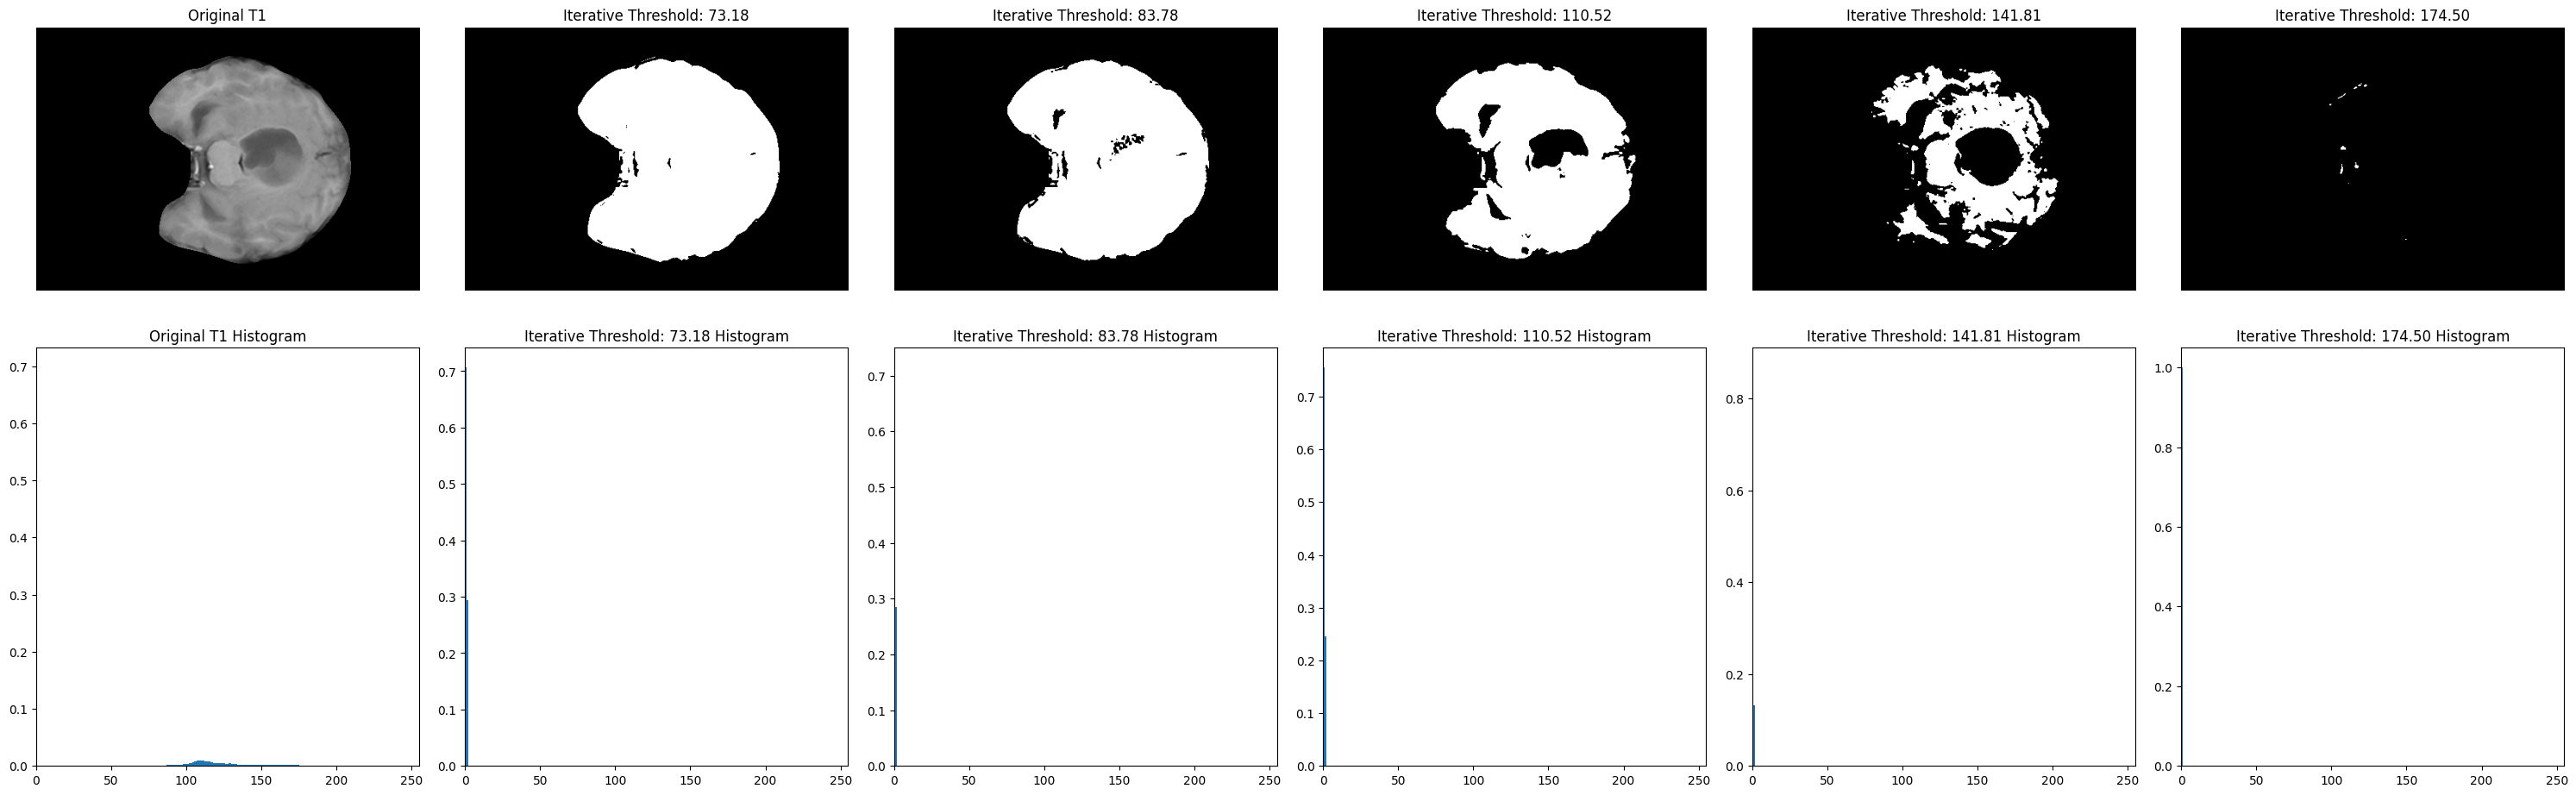

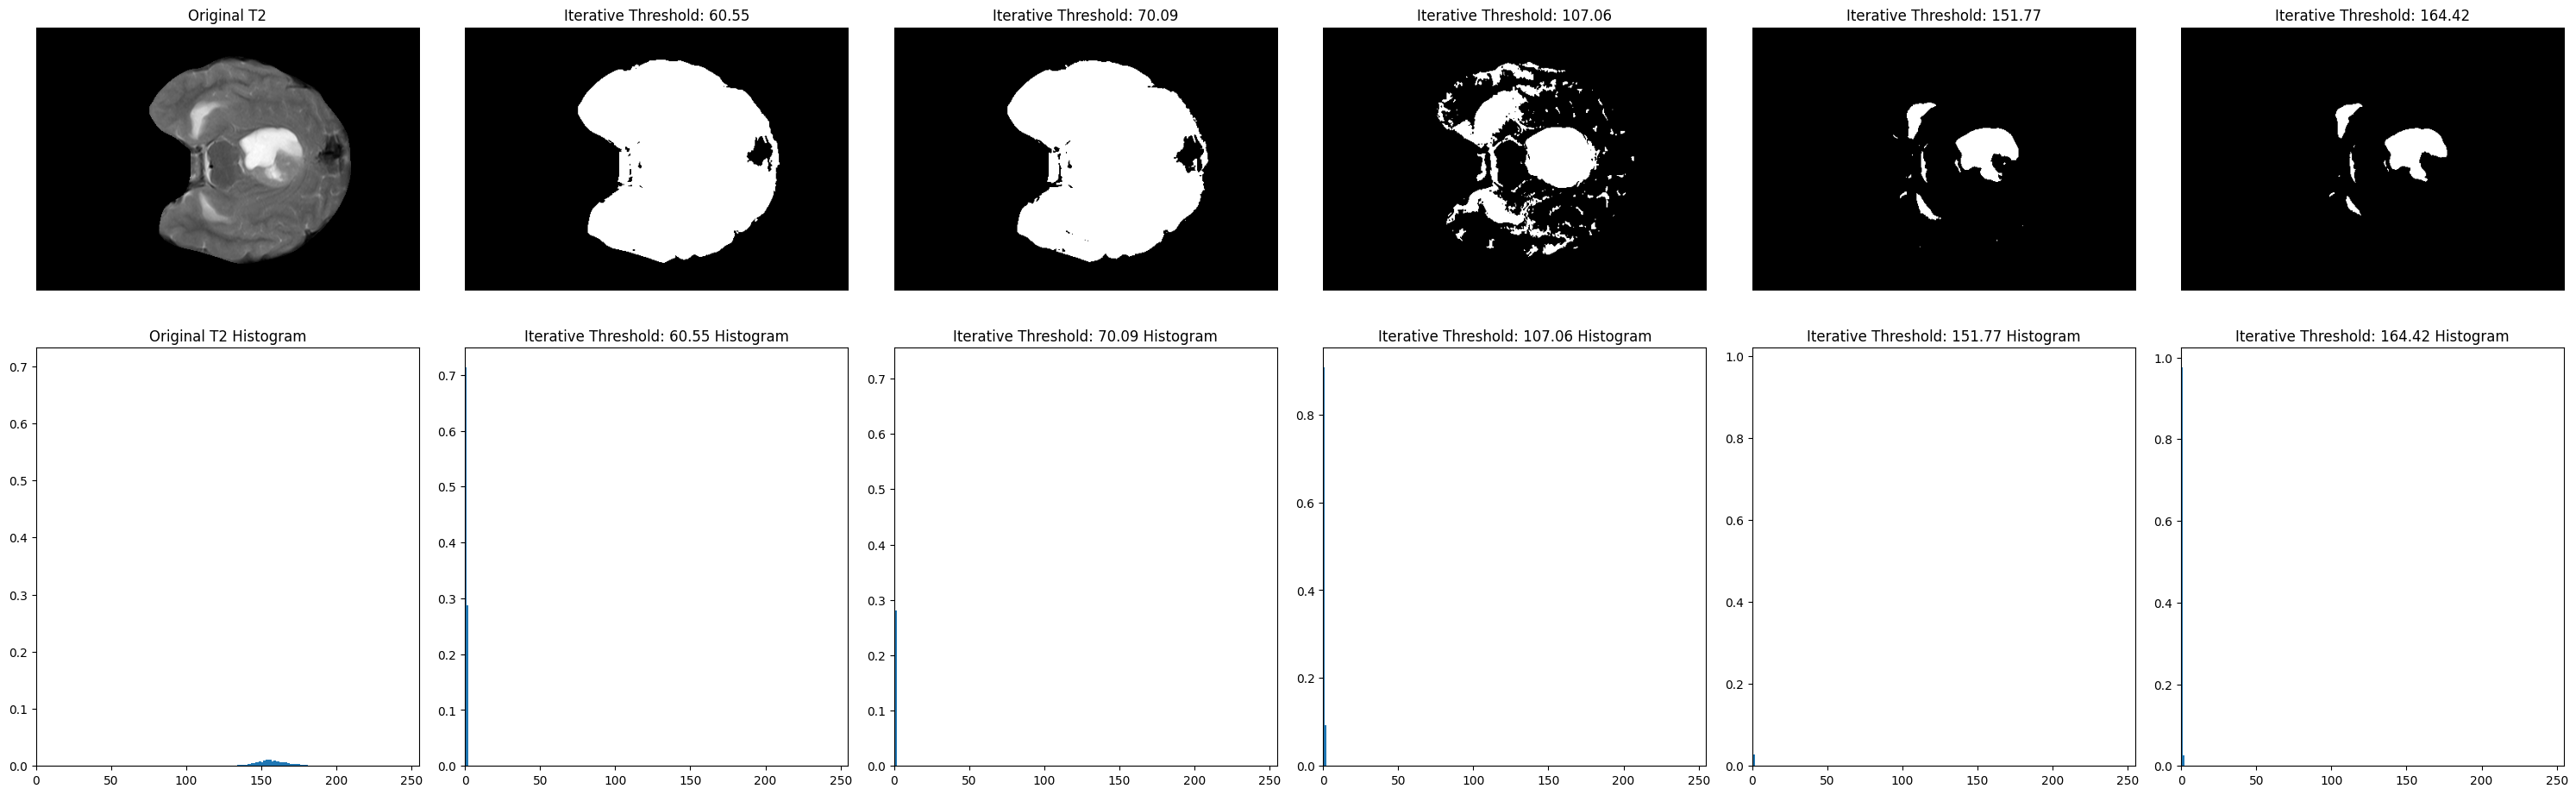

In [38]:
tolerance = 0
max_iterations = 1
T_init_list = [20, 50, 100, 150, 200]
result_T1 = {
    "images": [img_T1_normalized],
    "threshold": [],
    "titles": ["Original T1"]
}
result_T2 = {
    "images": [img_T2_normalized],
    "threshold": [],
    "titles": ["Original T2"]
}

# Apply iterative thresholding for each initial threshold
for T in T_init_list:
    mask, threshold = thresholdIterative(img_T1, T_init=T, tolerance=tolerance, max_iterations=max_iterations)
    result_T1["images"].append(mask)
    result_T1["threshold"].append(threshold)
    result_T1["titles"].append(f"Iterative Threshold: {threshold:.2f}")

    mask, threshold = thresholdIterative(img_T2, T_init=T, tolerance=tolerance, max_iterations=max_iterations)
    result_T2["images"].append(mask)
    result_T2["threshold"].append(threshold)
    result_T2["titles"].append(f"Iterative Threshold: {threshold:.2f}")

# print the thresholds
for i in range(len(T_init_list)):
    print(f"Iterative Threshold for T1 with initial T={T_init_list[i]}: {result_T1['threshold'][i]:.2f}")

for i in range(len(T_init_list)):
    print(f"Iterative Threshold for T2 with initial T={T_init_list[i]}: {result_T2['threshold'][i]:.2f}")


# Display the results
show_images_histogram(
    images=result_T1["images"],
    titles=result_T1["titles"]
)

show_images_histogram(
    images=result_T2["images"],
    titles=result_T2["titles"]
)

如果 `max_iterations` 较小（例如上面选取了迭代次数为 1 ）时，不同的 `T_init` 就会对结果有很大影响。

### 2.2 Implement Otsu's optimum thresholding algorithm to segment the lesion

Otsu Threshold for T1: 117


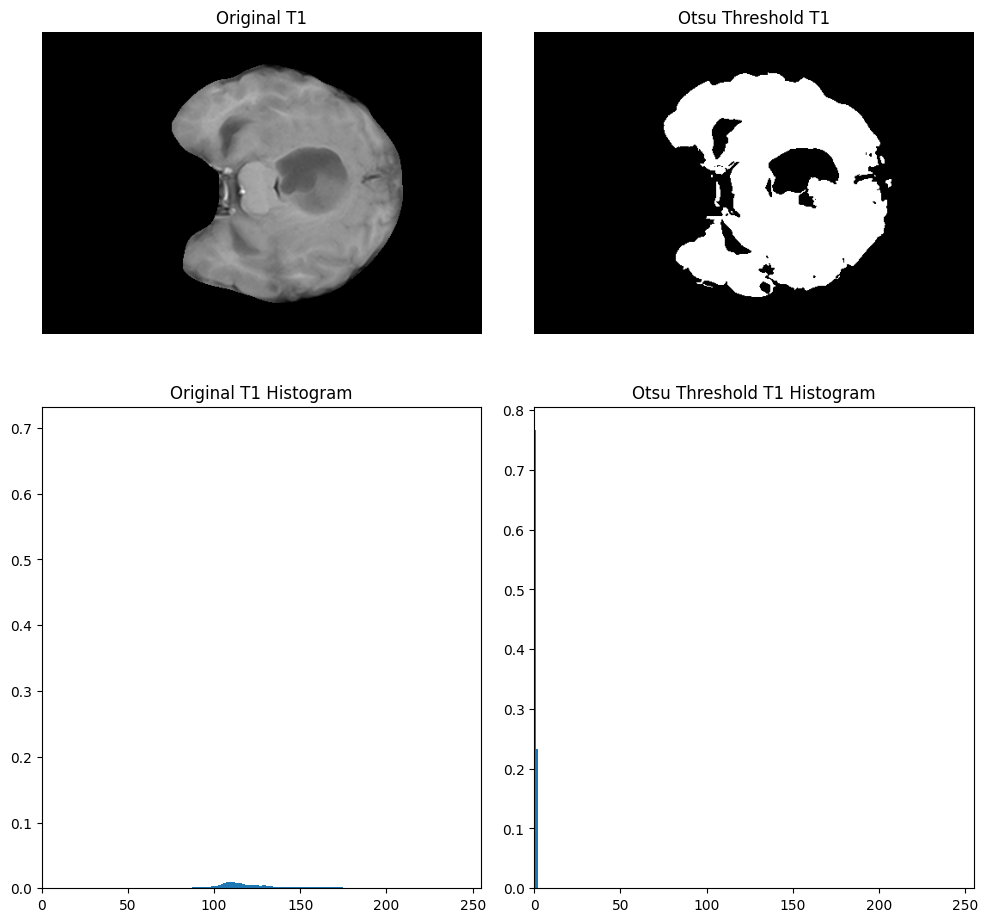

Otsu Threshold for T2: 152


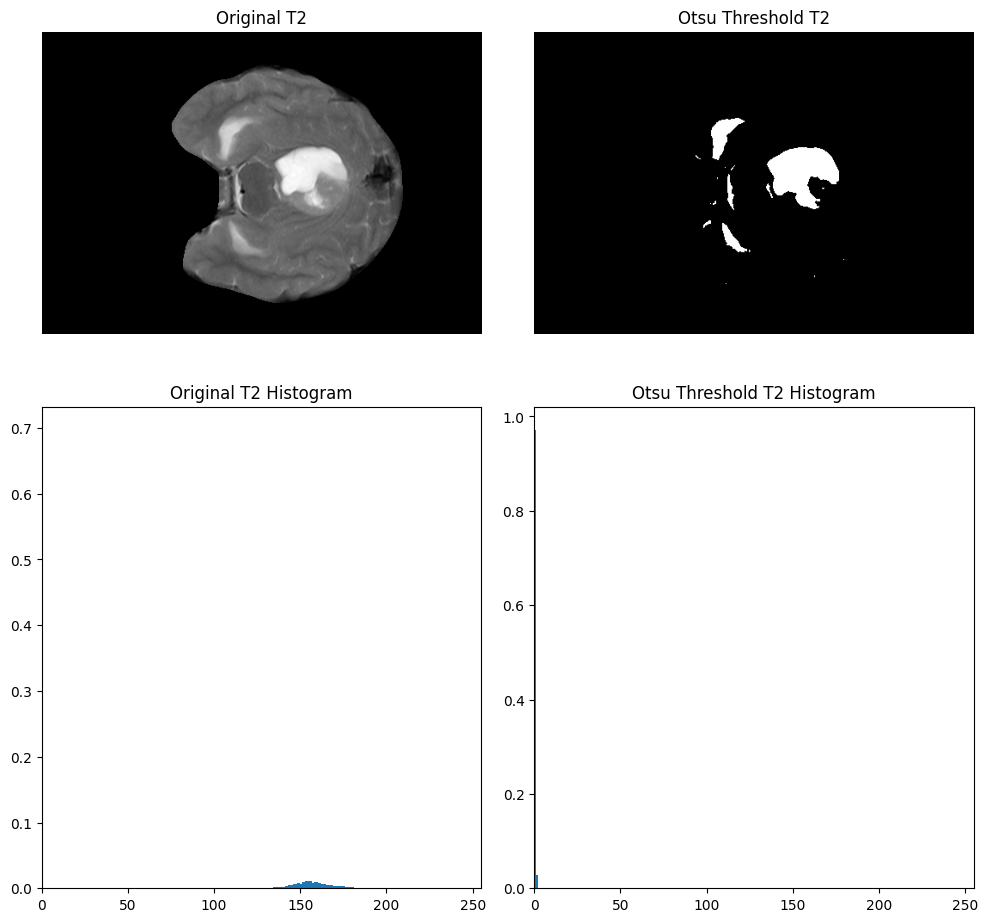

In [42]:
def thresholdOtsu(image, dtyle: np.dtype = np.uint8):

    # normalize the image
    image = normalize(image, dtype=dtyle)
    signal_mask = (image > 0)
    signal = image[signal_mask]

    # calculate the histogram
    hist, _ = np.histogram(signal, bins=256, range=(0,256))
    hist = hist / hist.sum()
    total_mean = np.sum(np.arange(256) * hist)

    # init parameters
    max_var = -1
    best_t = 0
    w0 = 0
    sum0 = 0

    # iterate through all possible thresholds
    for t in range(256):
        w0 += hist[t]
        if w0 == 0 or w0 == 1:
            continue
        sum0 += t * hist[t]
        mean0 = sum0 / w0
        w1 = 1 - w0
        sum1 = total_mean - sum0
        mean1 = sum1 / w1
        var_between = w0 * w1 * (mean0 - mean1) ** 2
        if var_between > max_var:
            max_var = var_between
            best_t = t
    mask = np.zeros_like(image, dtype=np.uint8)
    mask[image > best_t] = 255
    return mask, best_t


mask_T1_otsu, T1_otsu = thresholdOtsu(img_T1)
mask_T2_otsu, T2_otsu = thresholdOtsu(img_T2)

print(f"Otsu Threshold for T1: {T1_otsu}")
show_images_histogram(
    images=[img_T1_normalized, mask_T1_otsu],
    titles=["Original T1", "Otsu Threshold T1"]
)

print(f"Otsu Threshold for T2: {T2_otsu}")
show_images_histogram(
    images=[img_T2_normalized, mask_T2_otsu],
    titles=["Original T2", "Otsu Threshold T2"]
)

### 2.3 Compare the results

Iterative Threshold for T1: 116.28879911470014
Otsu Threshold for T1: 117

Iterative Threshold for T2: 151.3743447774998
Otsu Threshold for T2: 152


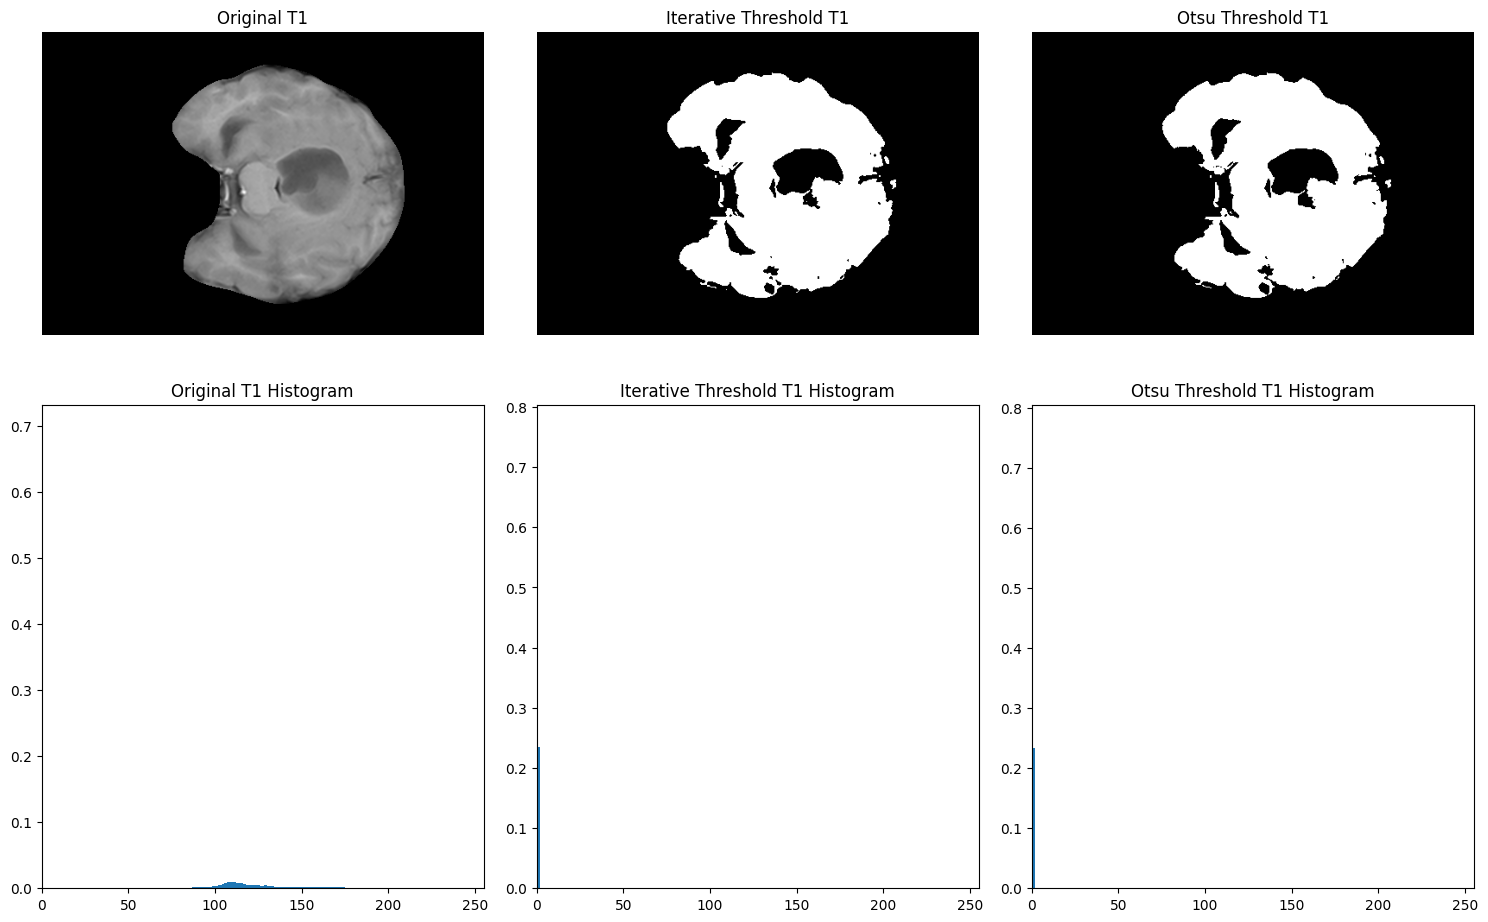

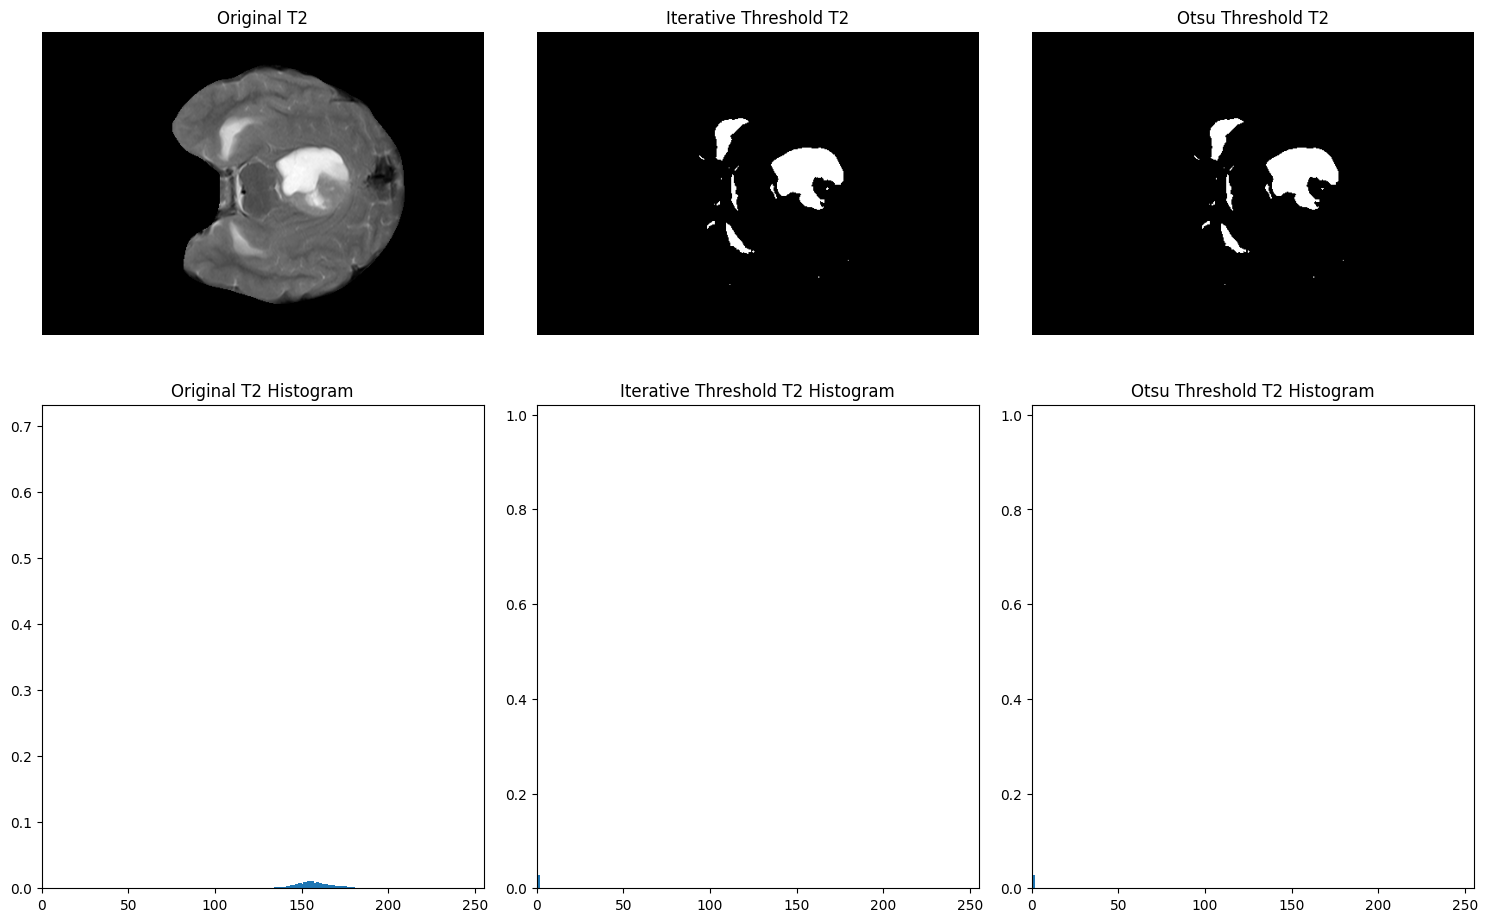

In [43]:
# iterative
T_init = 100
tolerance = 1
max_iterations = 100
mask_T1_iter, T1_iter = thresholdIterative(img_T1, T_init=T_init, tolerance=tolerance, max_iterations=max_iterations)
mask_T2_iter, T2_iter = thresholdIterative(img_T2, T_init=T_init, tolerance=tolerance, max_iterations=max_iterations)

# otsu
mask_T1_otsu, T1_otsu = thresholdOtsu(img_T1)
mask_T2_otsu, T2_otsu = thresholdOtsu(img_T2)

# print the thresholds
print(f"Iterative Threshold for T1: {T1_iter}")
print(f"Otsu Threshold for T1: {T1_otsu}")
print()
print(f"Iterative Threshold for T2: {T2_iter}")
print(f"Otsu Threshold for T2: {T2_otsu}")

# show the images
show_images_histogram(
    images=[img_T1_normalized, mask_T1_iter, mask_T1_otsu],
    titles=["Original T1", "Iterative Threshold T1", "Otsu Threshold T1"]
)

show_images_histogram(
    images=[img_T2_normalized, mask_T2_iter, mask_T2_otsu],
    titles=["Original T2", "Iterative Threshold T2", "Otsu Threshold T2"]
)

以上两种阈值分类方法的结果非常相近，用肉眼根本区分不出差异。但是从方法的原理出发还是有一点区别的，比如： Otsu 方法的复杂度与精度强相关，想要增大阈值的精度会使得算法复杂度大大提高（上面我的代码中精度为个位，因此最后计算出的阈值是整数）；而迭代法的复杂度则与迭代数量强相关，如果 `T_init` 定义的不好，需要很大的迭代数，导致非常耗时。

## Project 3: Segmentation